## How was data collected:

# Dataset availability, attributes and goal

[https://www.kaggle.com/datasets/mmakarovlab/serbia-car-sales-prices/data
](https://www.kaggle.com/datasets/mmakarovlab/serbia-car-sales-prices/data
)

The dataset contains data from a Serbian used car website; the data is real, collected by the publishing user in October 2024. The CSV file contains the following columns (18 columns, 8413 rows of data + header): 

- **views**: how many people viewed the advertisement
- **favorite**: how many people added the advertisement to their favorites
- **post_info**: when the advertisement was published/updated
- **price**: the price of the car in Euro
- **car_name**: the manufacturer and model name of the car
- **year**: the year the car was manufactured
- **A/C**: is there air conditioning in the car?
- **emission_class**: environmental classification (EURO standard)
- **seats_amount**: number of seats
- **horsepower**: horsepower (also in kW)
- **color**: the color of the car (bodywork)
- **car_mileage, km**: the car's mileage in km
- **engine_capacity, cc**: the engine displacement in cc
- **type_of_drive**: type of drive
- **doors**: number of doors
- **fuel**: type of fuel used
- **car_type**: body style
- **gearbox**: type of gearbox, number of gears

The data still needs cleaning (e.g., missing values), type casting (e.g., floating point number to integer), and many columns need simplification (e.g., keeping only horsepower, discarding kW).

**Goal:** Cleaning and then analyzing the data. Finding correlations between the price and the car's attributes. Using various machine learning methods to determine what price a car could worth based on it's features.

## Data Cleaning

#### Importing every package that we need

In [1]:
#install.packages("tidyverse")
#install.packages("dlookr")
#install.packages("skimr")
#install.packages("embed")
#install.packages("corrplot")
#install.packages("xgboost")
#install.packages("kernlab") 
#install.packages("plotly")
library(tidyverse)
library(recipes)
library(dlookr)
library(skimr)
library(corrplot)
library(tidymodels)
library(embed)
library(vip)
library(doParallel)
library(finetune)
library(patchwork)
library(knitr)
library(plotly)
library(htmltools)

set.seed(123)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Kapcsolódás csomaghoz: 'recipes'


The following object is masked from 'package:stringr':

    fixed


The following object is masked from 'package:stats':

    step


Registered S3 methods overwritten by 'dlookr':
  method          from  
  plot.transform  scales
  print.transform scales


Kapcsolódás csomaghoz: 'dlookr'


The following object is masked from 'package:tidyr':

    extract


T

In [2]:
cars_raw = read_csv("serbia_car_sales_price_2024.csv")

Rows: 8413 Columns: 18
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (11): post_info, car_name, A/C, emission_class, horsepower, color, type_...
dbl  (7): views, favorite, price, year, seats_amount, car_mileage, km, engin...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
head(cars_raw)

views,favorite,post_info,price,car_name,year,A/C,emission_class,seats_amount,horsepower,color,"car_mileage, km","engine_capacity, cc",type_of_drive,doors,fuel,car_type,gearbox
<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
58,0,posted a week ago,1100,Alfa Romeo 11.9,2002,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
55,0,posted 2 days ago,1100,Alfa Romeo 145,2000,manual A/C,Euro 3,5,106 HP (78 kW),gray,158546,1400,front,2/3 doors,petrol + gas,hatchback,"manual, 5 speeds"
136,4,posted 2 weeks ago,950,Alfa Romeo 145,1999,manual A/C,Euro 3,5,105 HP (77 kW),green,337000,1910,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
209,1,posted 4 weeks ago,500,Alfa Romeo 146,2000,manual A/C,Euro 3,5,120 HP (88 kW),gray,200000,1600,front,4/5 doors,petrol + gas,limousine,"manual, 5 speeds"
61,0,posted 2 days ago,111,Alfa Romeo 147,2024,automatic A/C,NA,5,116 HP (85 kW),gray,280000,1900,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
196,2,posted 4 weeks ago,2300,Alfa Romeo 147,2008,no A/C,NA,5,105 HP (77 kW),black,188000,1600,front,4/5 doors,petrol + gas,hatchback,"manual, 5 speeds"


In [4]:
str(cars_raw)

spc_tbl_ [8,413 × 18] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ views              : num [1:8413] 58 55 136 209 61 ...
 $ favorite           : num [1:8413] 0 0 4 1 0 2 1 6 16 0 ...
 $ post_info          : chr [1:8413] "posted a week ago" "posted 2 days ago" "posted 2 weeks ago" "posted 4 weeks ago" ...
 $ price              : num [1:8413] 1100 1100 950 500 111 2300 3500 2150 1350 2000 ...
 $ car_name           : chr [1:8413] "Alfa Romeo 11.9" "Alfa Romeo 145" "Alfa Romeo 145" "Alfa Romeo 146" ...
 $ year               : num [1:8413] 2002 2000 1999 2000 2024 ...
 $ A/C                : chr [1:8413] NA "manual A/C" "manual A/C" "manual A/C" ...
 $ emission_class     : chr [1:8413] NA "Euro 3" "Euro 3" "Euro 3" ...
 $ seats_amount       : num [1:8413] NA 5 5 5 5 5 5 5 5 5 ...
 $ horsepower         : chr [1:8413] NA "106 HP (78 kW)" "105 HP (77 kW)" "120 HP (88 kW)" ...
 $ color              : chr [1:8413] NA "gray" "green" "gray" ...
 $ car_mileage, km    : num [1:8413] NA 158546 337000 

In [5]:
summary(cars_raw)

     views            favorite        post_info             price      
 Min.   :    0.0   Min.   :  0.000   Length:8413        Min.   :  100  
 1st Qu.:   61.0   1st Qu.:  0.000   Class :character   1st Qu.: 1600  
 Median :  114.0   Median :  1.000   Mode  :character   Median : 3300  
 Mean   :  308.7   Mean   :  2.672                      Mean   : 4848  
 3rd Qu.:  245.0   3rd Qu.:  3.000                      3rd Qu.: 5950  
 Max.   :27770.0   Max.   :151.000                      Max.   :82000  
                                                                       
   car_name              year          A/C            emission_class    
 Length:8413        Min.   :1960   Length:8413        Length:8413       
 Class :character   1st Qu.:2003   Class :character   Class :character  
 Mode  :character   Median :2006   Mode  :character   Mode  :character  
                    Mean   :2006                                        
                    3rd Qu.:2010                           

There are some NA's and outliers (e.g. price or car_mileage, km)  

In [6]:
problems(cars_raw)

row,col,expected,actual,file
<int>,<int>,<chr>,<chr>,<chr>


#### Renaming columns for better readability

In [7]:
cars_raw <- cars_raw %>%
rename(post_date=post_info, price_eur=price, ac=`A/C`, seats=seats_amount, mileage_km=`car_mileage, km`, engine_capacity_cc=`engine_capacity, cc`)

#### Casting columns to integer and adding an ID column

In [8]:
cars_raw <- cars_raw %>%
mutate(across(c(views, favorite, price_eur, year, seats, mileage_km, engine_capacity_cc), as.integer)) %>%
mutate(id = row_number()) %>%
relocate(id, .before = 1)

Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `across(...)`.
Caused by warning:
! NAs introduced by coercion to integer range"


#### Cleaning and formatting post_date column

In [9]:
cars_raw <- cars_raw %>%
mutate(post_date = str_remove(post_date, "^(posted|updated)\\s?"))

In [10]:
sum(is.na(cars_raw$post_date))

cars_raw %>%
distinct(post_date)

[1] 0

post_date
<chr>
a week ago
2 days ago
2 weeks ago
4 weeks ago
5 days ago
6 days ago
3 weeks ago
yesterday
3 days ago


#### Cleaning ac, emission, horsepower and doors columns

In [11]:
sum(is.na(cars_raw$ac))

cars_raw %>%
distinct(ac)

[1] 10

ac
<chr>
NA
manual A/C
automatic A/C
no A/C


In [12]:
cars_raw <- cars_raw %>%
mutate(ac = str_trim(str_remove(ac, "A/C$"))) %>%
mutate(emission_class = str_remove(emission_class, "^Euro\\s?")) %>%
mutate(emission_class = as.integer(emission_class)) %>%
mutate(horsepower = str_extract(horsepower, "^[0-9]+") %>% as.numeric()) %>%
mutate(horsepower = as.integer(horsepower)) %>%
mutate(doors = str_trim(str_remove(doors, "doors$")))

In [13]:
cars_raw %>%
count(color, sort = TRUE)

# Color names are OK

color,n
<chr>,<int>
gray,2628
black,1699
white,1068
blue,889
red,582
teget,364
silver,312
green,275
brown,113


#### Splitting gearbox column into type and speeds

In [14]:
cars_raw %>%
count(gearbox, sort = TRUE)

gearbox,n
<chr>,<int>
"manual, 5 speeds",4645
"manual, 6 speeds",2323
automatic,1164
"manual, 4 speeds",168
semi-automatic,85
"manual, multiple speeds",18
NA,10


In [15]:
cars_raw <- cars_raw %>%
  mutate(
    # Splitting on comma (if there's none, the 'speeds_raw' will be NA)
    speeds_raw = str_split_i(gearbox, ", ", 2),
    gearbox = str_split_i(gearbox, ", ", 1),
    
    
    # Extracting number from speeds_raw, if there's none it will be 0
    speeds = str_extract(speeds_raw, "[0-9]+") %>% as.numeric(),
    speeds = ifelse(is.na(speeds), 0, speeds)
  ) %>%
  select(-speeds_raw) %>%
  mutate(speeds = as.integer(speeds))

#### Transforming car_name into brand and model columns

In [16]:
brands <- c("Alfa Romeo", "Audi", "BMW", "Chevrolet", "Chrysler", "Citroen", 
           "Dacia", "Daewoo", "Daihatsu", "Dodge", "Fiat", "Ford", "Honda", 
           "Hyundai", "Isuzu", "Iveco", "Jaguar", "Jeep", "Kia", "Lada", 
           "Lancia", "Land Rover", "Lexus", "Maserati", "Mazda", "Mercedes", 
           "MG", "Mini", "Mitsubishi", "Moskwitch", "Nissan", "Opel", 
           "Peugeot", "Pontiac", "Porsche", "Renault", "Rover", "Saab", 
           "Seat", "Skoda", "Smart", "SsangYong", "Subaru", "Suzuki", 
           "Tesla", "Toyota", "Trabant", "UAZ", "Volkswagen", "Volvo", 
           "VW", "Wartburg", "Zastava")

# Creating regex
brand_regex <- paste0("^(", paste(sort(brands, decreasing = TRUE), collapse = "|"), ")")

cars_raw <- cars_raw %>%
  mutate(
    brand = str_extract(car_name, brand_regex),
    model = str_remove(car_name, brand_regex) %>% str_trim()
  ) %>%
  select(-car_name) %>% 
  relocate(brand, model, .after = 3)

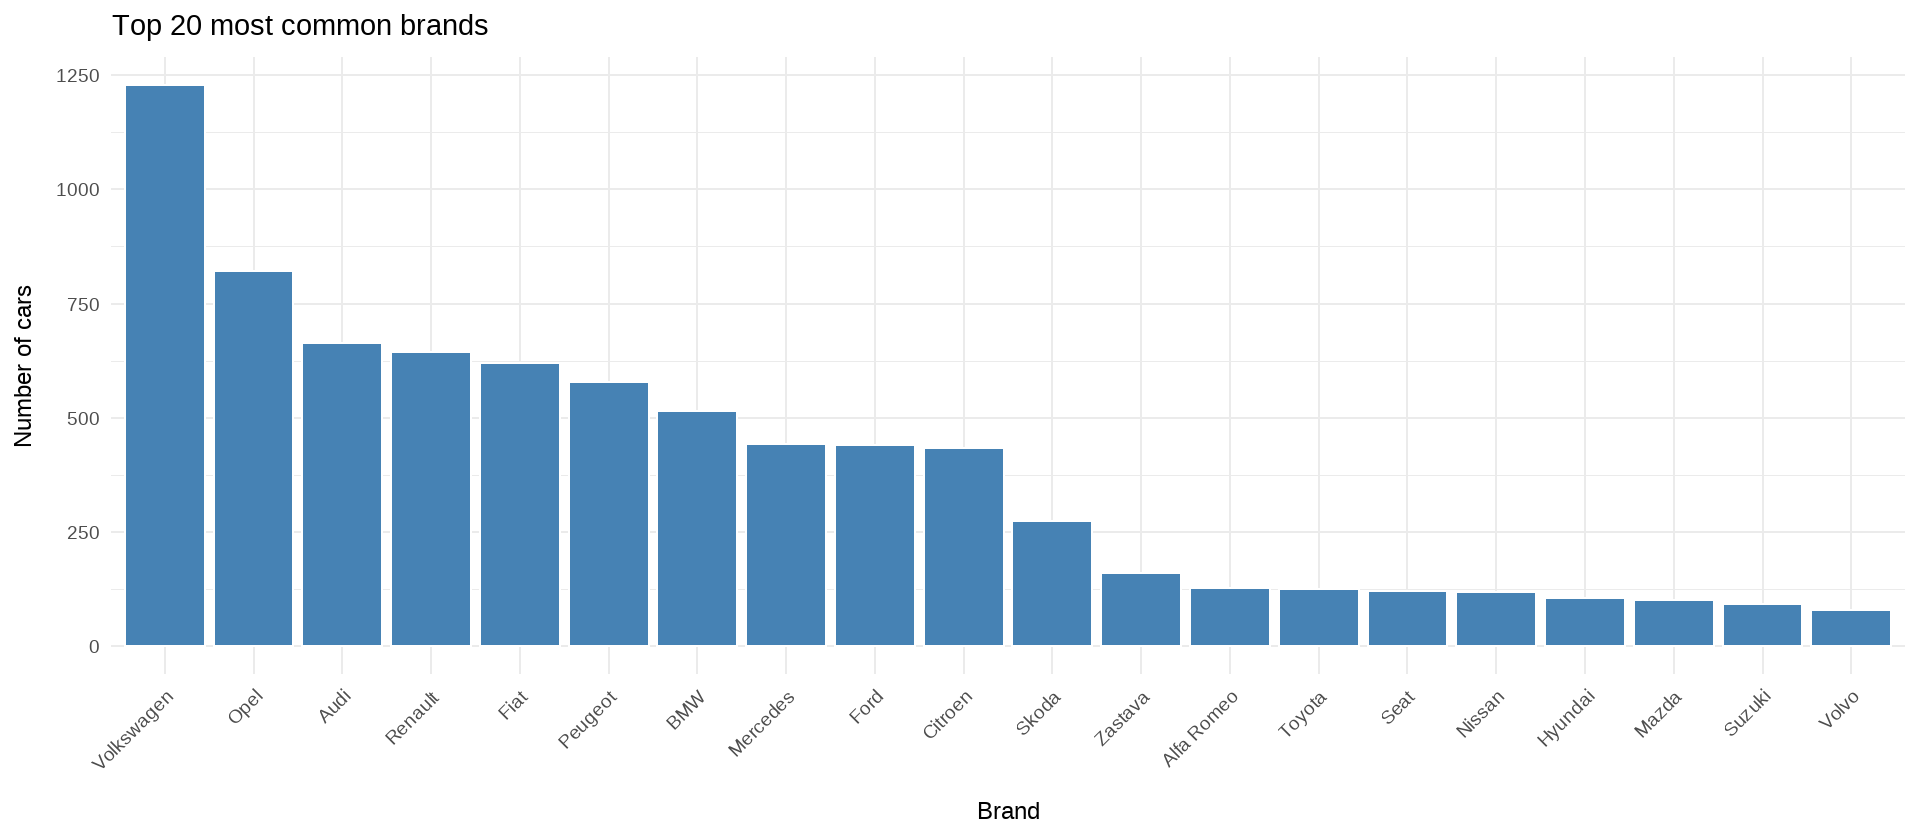

In [17]:
options(repr.plot.width = 16, repr.plot.height = 7)

cars_raw %>%
  count(brand) %>%
  slice_max(n, n = 20) %>%
  ggplot(aes(x = reorder(brand, -n), y = n)) +
  geom_col(fill = "steelblue", color = "white") +
  theme_minimal(base_size = 18) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title = "Top 20 most common brands",
    x = "Brand",
    y = "Number of cars"
  )

There are 3 cars with VW instead of Volkswagen

In [18]:
cars_raw <- cars_raw %>%
mutate(brand = str_replace(brand, "^VW$", "Volkswagen"))

#### Transforming post_date into days_passed column
This column won't be used for price prediction, but it's cleaned for future ML use cases

In [19]:
cars_raw <- cars_raw %>%
  mutate(post_date = case_when(
    str_detect(post_date, "today")      ~ 0L,
    str_detect(post_date, "yesterday")  ~ 1L,
    str_detect(post_date, "2 days")     ~ 2L,
    str_detect(post_date, "3 days")     ~ 3L,
    str_detect(post_date, "4 days")     ~ 4L,
    str_detect(post_date, "5 days")     ~ 5L,
    str_detect(post_date, "6 days")     ~ 6L,
    str_detect(post_date, "a week ago") ~ 7L,
    str_detect(post_date, "2 weeks")    ~ 14L,
    str_detect(post_date, "3 weeks")    ~ 21L,
    str_detect(post_date, "4 weeks")    ~ 28L,
    str_detect(post_date, "month")      ~ 30L,
    TRUE ~ NA_integer_
  )) %>%
rename(days_passed=post_date)

In [20]:
str(cars_raw)

tibble [8,413 × 21] (S3: tbl_df/tbl/data.frame)
 $ id                : int [1:8413] 1 2 3 4 5 6 7 8 9 10 ...
 $ views             : int [1:8413] 58 55 136 209 61 196 133 290 2629 89 ...
 $ favorite          : int [1:8413] 0 0 4 1 0 2 1 6 16 0 ...
 $ brand             : chr [1:8413] "Alfa Romeo" "Alfa Romeo" "Alfa Romeo" "Alfa Romeo" ...
 $ model             : chr [1:8413] "11.9" "145" "145" "146" ...
 $ days_passed       : int [1:8413] 7 2 14 28 2 28 5 6 7 7 ...
 $ price_eur         : int [1:8413] 1100 1100 950 500 111 2300 3500 2150 1350 2000 ...
 $ year              : int [1:8413] 2002 2000 1999 2000 2024 2008 2008 2008 2008 2007 ...
 $ ac                : chr [1:8413] NA "manual" "manual" "manual" ...
 $ emission_class    : int [1:8413] NA 3 3 3 NA NA 4 4 4 4 ...
 $ seats             : int [1:8413] NA 5 5 5 5 5 5 5 5 5 ...
 $ horsepower        : int [1:8413] NA 106 105 120 116 105 170 90 120 105 ...
 $ color             : chr [1:8413] NA "gray" "green" "gray" ...
 $ mileage_km      

In [21]:
summary(cars_raw)

       id           views            favorite          brand          
 Min.   :   1   Min.   :    0.0   Min.   :  0.000   Length:8413       
 1st Qu.:2104   1st Qu.:   61.0   1st Qu.:  0.000   Class :character  
 Median :4207   Median :  114.0   Median :  1.000   Mode  :character  
 Mean   :4207   Mean   :  308.7   Mean   :  2.672                     
 3rd Qu.:6310   3rd Qu.:  245.0   3rd Qu.:  3.000                     
 Max.   :8413   Max.   :27770.0   Max.   :151.000                     
                                                                      
    model            days_passed      price_eur          year     
 Length:8413        Min.   : 0.00   Min.   :  100   Min.   :1960  
 Class :character   1st Qu.: 4.00   1st Qu.: 1600   1st Qu.:2003  
 Mode  :character   Median : 7.00   Median : 3300   Median :2006  
                    Mean   : 9.64   Mean   : 4848   Mean   :2006  
                    3rd Qu.:14.00   3rd Qu.: 5950   3rd Qu.:2010  
                    Max.   :30

#### Checking the values of the columns (missing or unrealistic values, outliers etc.)

In [22]:
cars_raw %>%
filter(views < favorite)

id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
680,0,1,Audi,A6,0,3000,2004,automatic,3,⋯,150,red,222000,1790,front,4/5,petrol + gas,caravan,manual,5
727,0,1,Audi,A8,0,4450,2005,automatic,3,⋯,237,black,340000,3000,4x4,4/5,diesel,limousine,automatic,0
4952,0,1,Opel,Zafira,0,650,2004,manual,3,⋯,101,bordeaux,290884,1995,front,4/5,diesel,minivan (MPV),manual,5
5256,0,2,Peugeot,306,0,350,2001,no,3,⋯,75,gray,280000,1899,front,4/5,diesel,caravan,manual,5
6685,0,1,Smart,Fortwo,0,120,2001,no,3,⋯,61,black,12100,599,back,2/3,petrol,coupe,manual,6


In [23]:
cars_raw <- cars_raw %>%
filter(views >= favorite)

#### Filtering outliers in price_eur

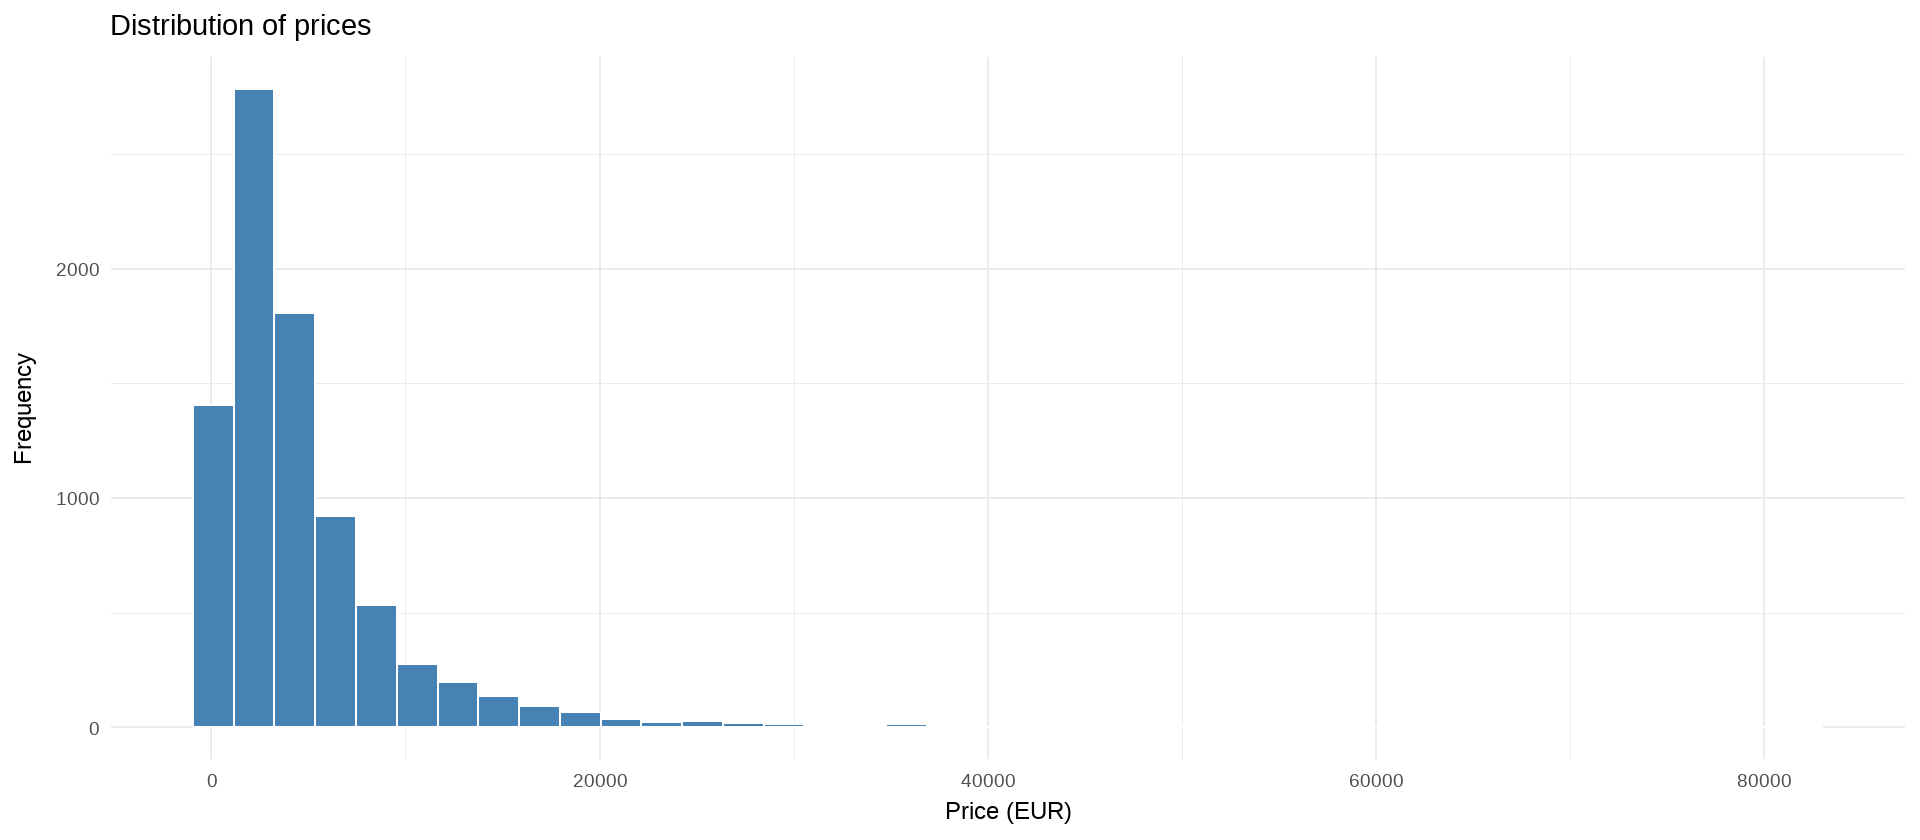

In [24]:
options(repr.plot.width = 16, repr.plot.height = 7)

ggplot(cars_raw, aes(x = price_eur)) +
  geom_histogram(fill = "steelblue", color = "white", bins = 40) +
  theme_minimal(base_size = 18) +
  labs(title = "Distribution of prices", x = "Price (EUR)", y = "Frequency")

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


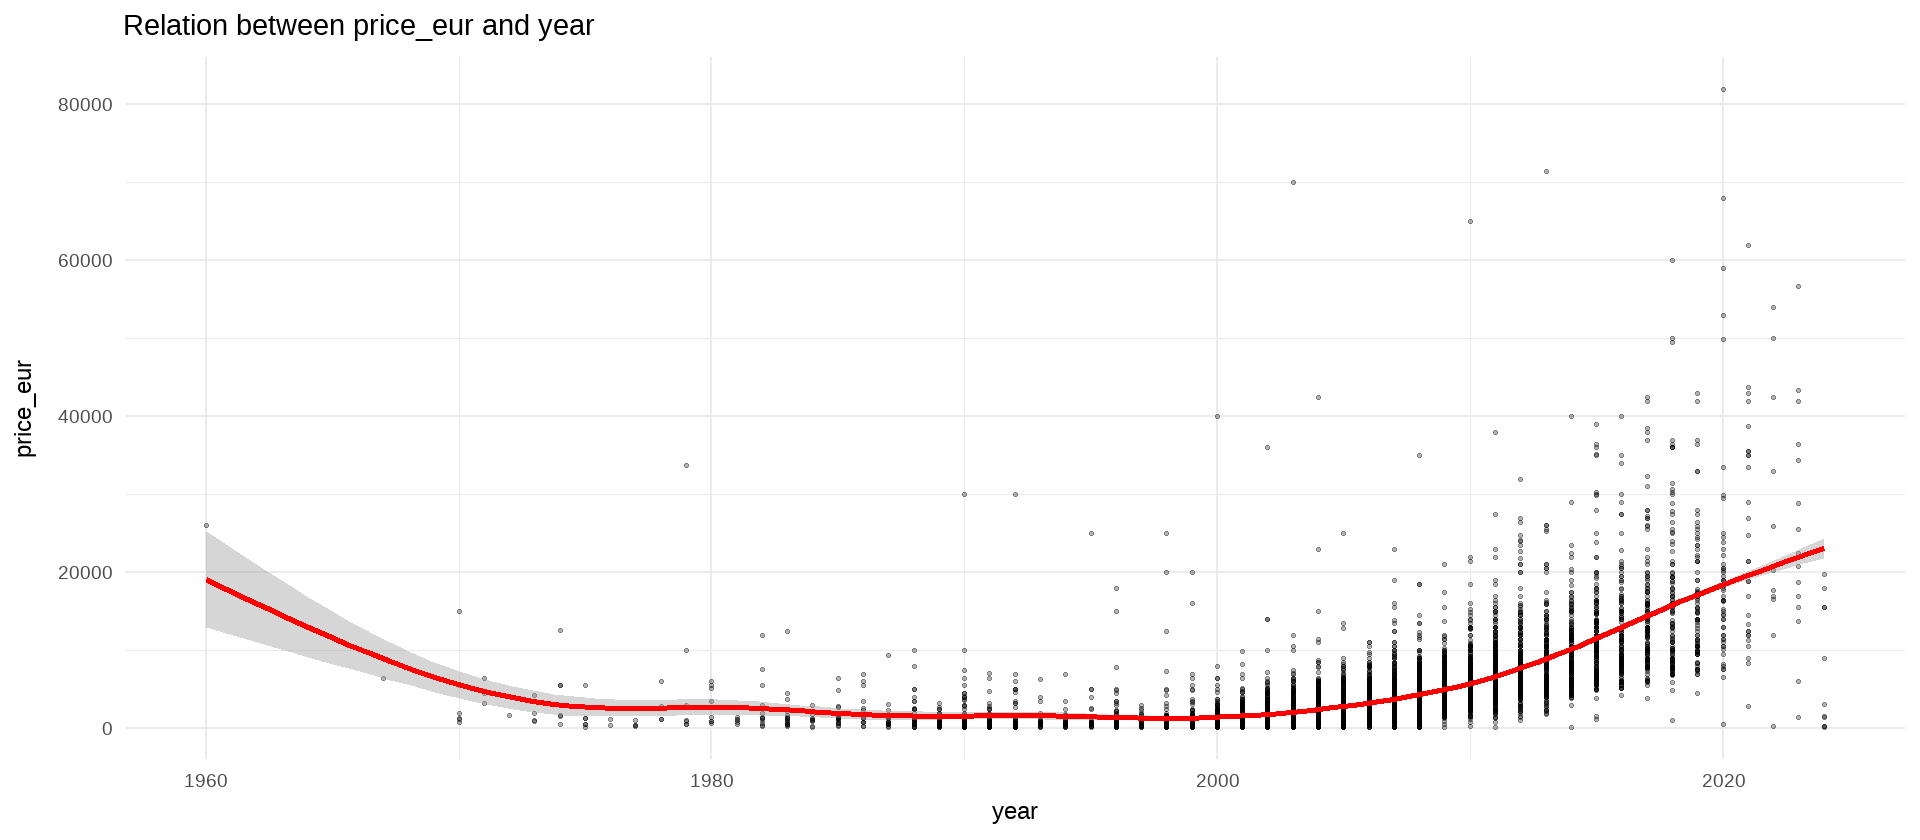

In [25]:
ggplot(cars_raw, aes(x = year, y = price_eur)) +
  geom_point(size = 0.9, alpha = 0.3, color = "black") +
  geom_smooth(method = "gam", color = "red", se = TRUE) +
  theme_minimal(base_size = 18) +
  labs(title = "Relation between price_eur and year")

In [26]:
Q1 <- quantile(cars_raw$price_eur, .25)
Q3 <- quantile(cars_raw$price_eur, .75)
IQR_value <- IQR(cars_raw$price_eur)

lower_bound <- Q1 - 1.5 * IQR_value
upper_bound <- Q3 + 1.5 * IQR_value

outliers <- cars_raw$price_eur[cars_raw$price_eur < lower_bound | cars_raw$price_eur > upper_bound]
length(outliers)
summary(outliers)

[1] 605

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  12490   14000   16500   20158   22000   82000 

In [27]:
# Also filtering cars that have unrealistic prices (affects only few rows)

cars_raw <- cars_raw %>%
filter(!(price_eur < 200 & brand %in% c('Audi', 'Mercedes'))) %>%
filter(!(price_eur < 800 & year > 2010)) %>%
filter(price_eur < 16500)    # These expensive cars ruin the price prediction, there are few hundred of them

#### Filtering NA's

In [28]:
cars_raw %>%
count(emission_class)

emission_class,n
<int>,<int>
1,215
2,338
3,1811
4,2495
5,1406
6,520
NA,1293


In [29]:
cars_raw %>%
count(seats)

cars_raw %>%
filter(is.na(seats))

seats,n
<int>,<int>
2,221
3,37
4,536
5,6894
6,36
7,323
8,5
9,18
NA,8


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,58,0,Alfa Romeo,11.9,7,1100,2002,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
232,36,1,Audi,A3,7,4300,2007,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
1359,152,2,Chevrolet,Tacuma,14,400,2006,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
1704,18,0,Citroen,DS3,14,6000,2012,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
6645,664,5,Skoda,Yeti,14,6600,2010,NA,NA,⋯,NA,NA,181000,NA,4x4,NA,diesel,suv,NA,0
8248,8124,68,Volkswagen,Buba,14,6500,1967,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8249,86,1,Volkswagen,Buba,4,3199,1971,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8276,156,6,Zastava,101,4,1250,1983,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,coupe,NA,0


In [30]:
# dropping rows with unrealistic HP values (over 500 HP for cars that have way less in normal case)
cars_raw <- cars_raw %>%
filter(!id %in% c(36, 1878, 2431, 3271, 4635, 6714))

In [31]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                 8               1289                  8                  8 
             color         mileage_km engine_capacity_cc      type_of_drive 
                 8                 12                  8                  7 
             doors               fuel           car_type            gearbox 
                 8                  7                  6                  8 
            speeds 
                 0

In [32]:
cars_raw <- cars_raw %>%
filter(horsepower > 20)

# Also filtered rows with NA's at horsepower (and this way a lot of columns with NA's were filtered)

In [33]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                 0               1274                  0                  0 
             color         mileage_km engine_capacity_cc      type_of_drive 
                 0                  5                  0                  0 
             doors               fuel           car_type            gearbox 
                 0                  0                  0                  0 
            speeds 
                 0

#### Cleaning mileage_km, engine_capacity_cc and car_type

In [34]:
# Assumption: if it's over 1.000.000 it's likely that the decimal part was also written there so I divide with 10.
# If it's still over 1.000.000 after the division the row gets dropped.
# (This is a usual mistake by the users on car sale websites)
cars_raw <- cars_raw %>%
mutate(mileage_km = if_else(mileage_km > 1000000, 
                            mileage_km / 10, 
                            mileage_km)) %>%
mutate(mileage_km = round(mileage_km)) %>%
filter(mileage_km < 999999) %>%

# Assumption: the low mileages can be a mistake by the owner e.g. 265 instead of 265.000
# These rows all looked like they fit this assumption based on their other attributes
# (This is also a usual mistake, writing 150k instead of 150.000)
mutate(mileage_km = if_else(mileage_km > 80 & mileage_km < 400, 
                            mileage_km * 1000, 
                            mileage_km))

In [35]:
cars_raw <- cars_raw %>%
filter(mileage_km > 1000)

In [36]:
# A 0 was likely missed at the end for these cars, it makes sense based on their other attributes 
cars_raw <- cars_raw %>%
mutate(engine_capacity_cc = if_else(engine_capacity_cc < 300,
                                    engine_capacity_cc * 10,
                                    engine_capacity_cc)) %>%
filter(!id %in% c(792, 1056, 1057, 4950, 6860))
# dropping unrealistic values (over 5000 CC for not fitting cars, e.g. ~10000 CC for an Opel Zafira)

In [37]:
cars_raw <- cars_raw %>%
mutate(car_type = str_replace(car_type, "minivan \\(MPV\\)", "minivan"))

In [38]:
cars_raw <- cars_raw %>%
mutate(across(c(mileage_km, engine_capacity_cc), as.integer))

#### Adding column 'kms_per_year'

In [39]:
cars_raw <- cars_raw %>%
add_column(kms_per_year = as.integer(round(cars_raw$mileage_km / (2024 - cars_raw$year + 1))), .after = "mileage_km")

In [40]:
problems(cars_raw)

In [41]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                 0               1257                  0                  0 
             color         mileage_km       kms_per_year engine_capacity_cc 
                 0                  0                  0                  0 
     type_of_drive              doors               fuel           car_type 
                 0                  0                  0                  0 
           gearbox             speeds 
                 0                  0

All NA's are gone, except for emission_class (it will be cleaned with the recipe later)

#### Checking the data before proceeding

In [42]:
summary(cars_raw)

       id           views            favorite         brand          
 Min.   :   2   Min.   :    0.0   Min.   : 0.000   Length:7987       
 1st Qu.:2144   1st Qu.:   61.0   1st Qu.: 0.000   Class :character  
 Median :4270   Median :  114.0   Median : 1.000   Mode  :character  
 Mean   :4232   Mean   :  302.3   Mean   : 2.658                     
 3rd Qu.:6314   3rd Qu.:  241.5   3rd Qu.: 3.000                     
 Max.   :8413   Max.   :17011.0   Max.   :73.000                     
                                                                     
    model            days_passed       price_eur          year     
 Length:7987        Min.   : 0.000   Min.   :  100   Min.   :1970  
 Class :character   1st Qu.: 4.000   1st Qu.: 1600   1st Qu.:2003  
 Mode  :character   Median : 7.000   Median : 3200   Median :2006  
                    Mean   : 9.671   Mean   : 4073   Mean   :2006  
                    3rd Qu.:14.000   3rd Qu.: 5500   3rd Qu.:2010  
                    Max.   :30.0

In [43]:
glimpse(cars_raw)

Rows: 7,987
Columns: 22
$ id                 <int> 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17…
$ views              <int> 55, 136, 209, 196, 133, 290, 2629, 89, 64, 1265, 11…
$ favorite           <int> 0, 4, 1, 2, 1, 6, 16, 0, 0, 17, 2, 4, 16, 0, 4, 4, …
$ brand              <chr> "Alfa Romeo", "Alfa Romeo", "Alfa Romeo", "Alfa Rom…
$ model              <chr> "145", "145", "146", "147", "147", "147", "147", "1…
$ days_passed        <int> 2, 14, 28, 28, 5, 6, 7, 7, 7, 7, 21, 7, 14, 2, 7, 2…
$ price_eur          <int> 1100, 950, 500, 2300, 3500, 2150, 1350, 2000, 2500,…
$ year               <int> 2000, 1999, 2000, 2008, 2008, 2008, 2008, 2007, 200…
$ ac                 <chr> "manual", "manual", "manual", "no", "automatic", "m…
$ emission_class     <int> 3, 3, 3, NA, 4, 4, 4, 4, NA, 5, 4, 3, 3, NA, 3, NA,…
$ seats              <int> 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, …
$ horsepower         <int> 106, 105, 120, 105, 170, 90, 120, 105, 105, 120, 12…
$ color         

In [44]:
skim(cars_raw)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,brand,0,1.0000000,2,10,0,50,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,model,0,1.0000000,1,25,0,639,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,ac,0,1.0000000,2,9,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,color,0,1.0000000,3,12,0,19,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,type_of_drive,0,1.0000000,3,5,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,doors,0,1.0000000,3,3,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,fuel,0,1.0000000,3,12,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,car_type,0,1.0000000,3,9,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,gearbox,0,1.0000000,6,14,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA


In [45]:
diagnose(cars_raw)

variables,types,missing_count,missing_percent,unique_count,unique_rate
<chr>,<chr>,<int>,<dbl>,<int>,<dbl>
id,integer,0,0.00000,7987,1.0000000000
views,integer,0,0.00000,1170,0.1464880431
favorite,integer,0,0.00000,53,0.0066357831
brand,character,0,0.00000,50,0.0062601728
model,character,0,0.00000,639,0.0800050081
days_passed,integer,0,0.00000,12,0.0015024415
price_eur,integer,0,0.00000,620,0.0776261425
year,integer,0,0.00000,55,0.0068861901
ac,character,0,0.00000,3,0.0003756104


#### Data cleaning is done

In [46]:
cars <- cars_raw
head(cars, 8)

id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
2,55,0,Alfa Romeo,145,2,1100,2000,manual,3,⋯,gray,158546,6342,1400,front,2/3,petrol + gas,hatchback,manual,5
3,136,4,Alfa Romeo,145,14,950,1999,manual,3,⋯,green,337000,12962,1910,front,2/3,diesel,hatchback,manual,5
4,209,1,Alfa Romeo,146,28,500,2000,manual,3,⋯,gray,200000,8000,1600,front,4/5,petrol + gas,limousine,manual,5
6,196,2,Alfa Romeo,147,28,2300,2008,no,NA,⋯,black,188000,11059,1600,front,4/5,petrol + gas,hatchback,manual,5
7,133,1,Alfa Romeo,147,5,3500,2008,automatic,4,⋯,black,255000,15000,1929,front,4/5,diesel,hatchback,manual,6
8,290,6,Alfa Romeo,147,6,2150,2008,manual,4,⋯,black,214000,12588,1600,front,4/5,petrol + gas,hatchback,manual,5
9,2629,16,Alfa Romeo,147,7,1350,2008,automatic,4,⋯,white,315000,18529,1910,front,4/5,diesel,hatchback,manual,6
10,89,0,Alfa Romeo,147,7,2000,2007,no,4,⋯,black,176853,9825,1597,front,4/5,petrol,hatchback,manual,5


## Statistics and diagrams

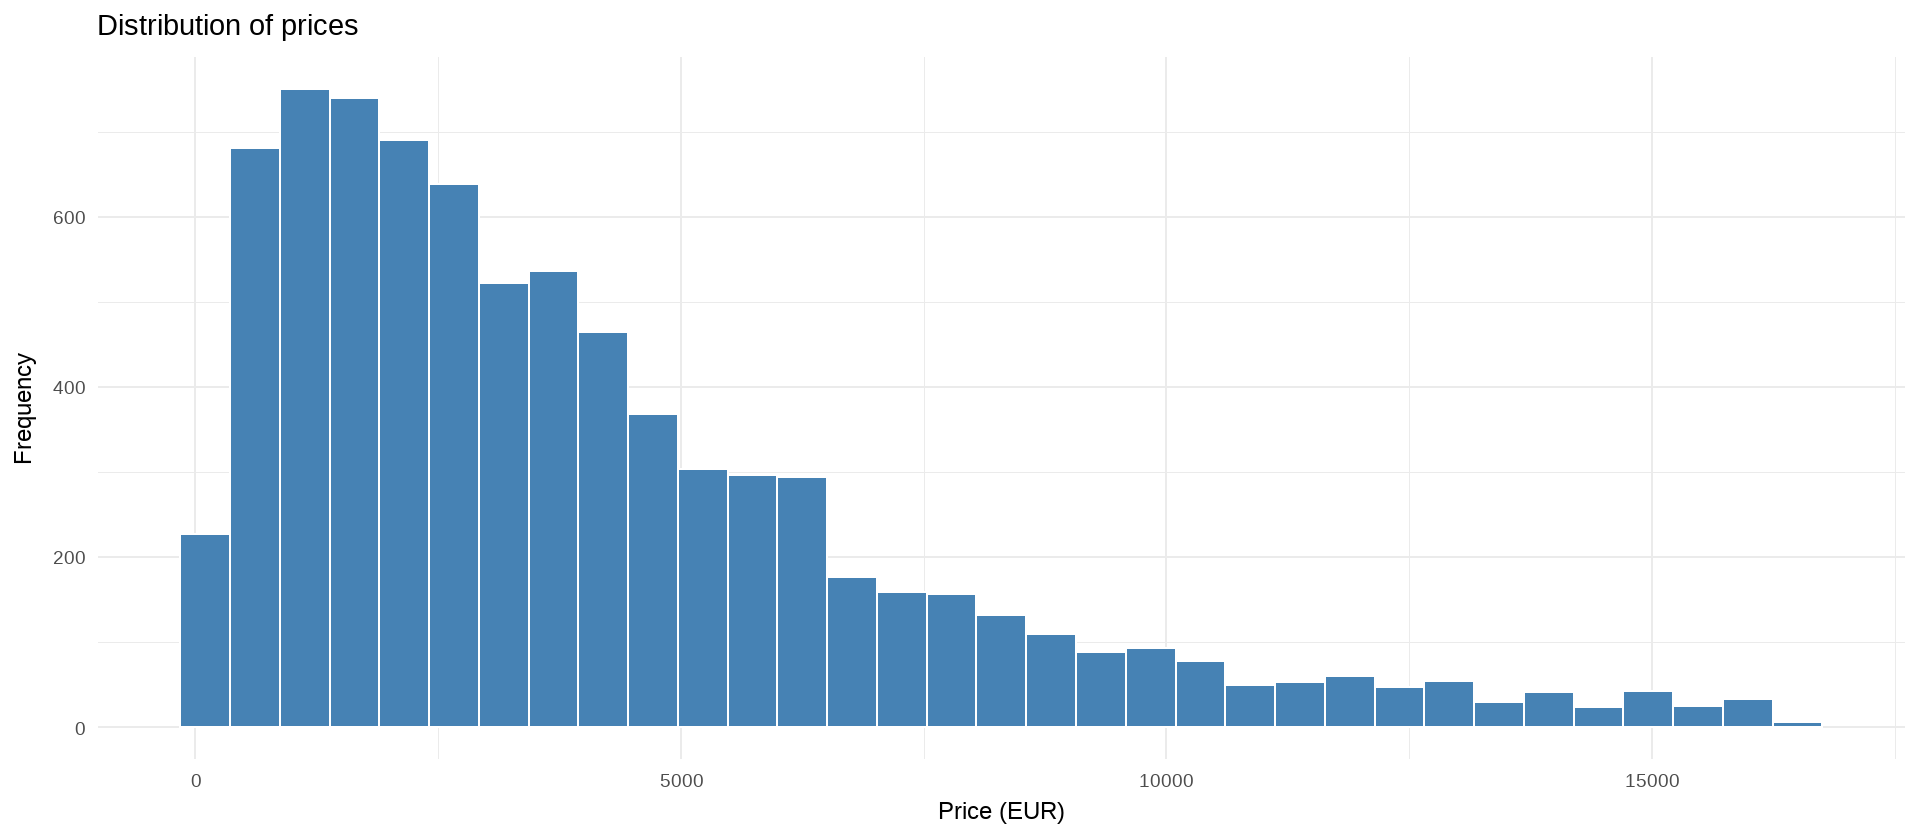

In [47]:
options(repr.plot.width = 16, repr.plot.height = 7)

ggplot(cars, aes(x = price_eur)) +
  geom_histogram(fill = "steelblue", color = "white", bins = 33) +
  theme_minimal(base_size = 18) +
  labs(title = "Distribution of prices", x = "Price (EUR)", y = "Frequency")

Most of the prices are really low (~1000-3000 EUR). That's why the rows with a price over 16.500 were dismissed.

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


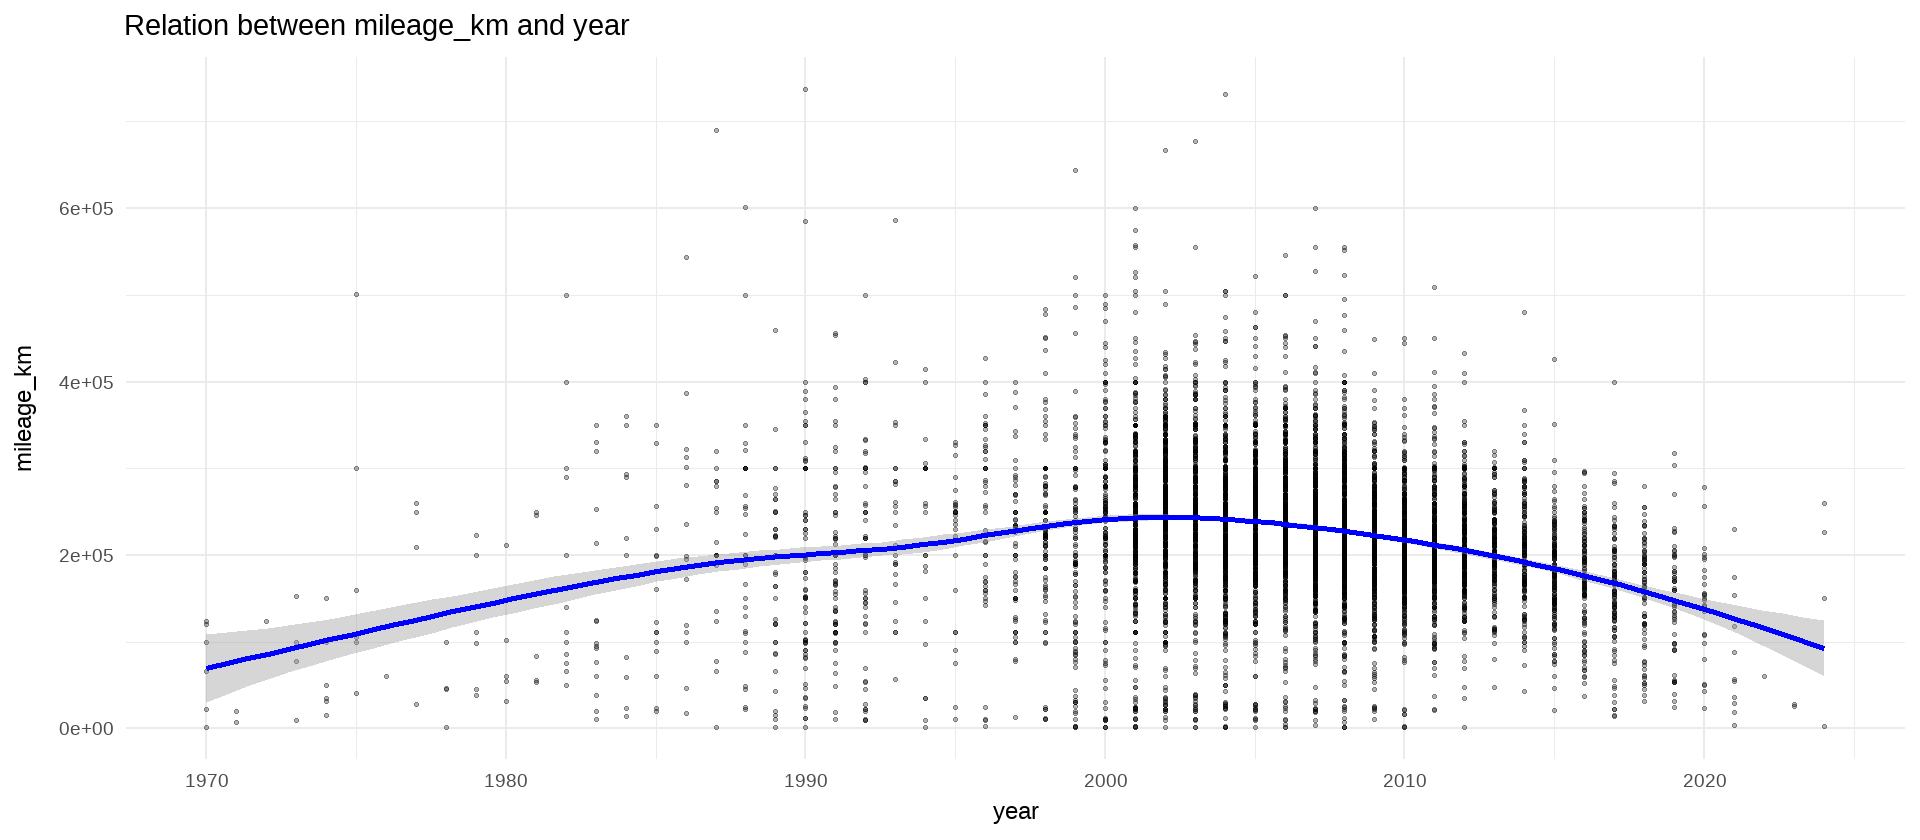

In [48]:
ggplot(cars, aes(x=year, y=mileage_km)) +
  geom_point(color="black", size=0.9, alpha=0.3) +
  geom_smooth(method = "gam", color = "blue", se = TRUE) +
  theme_minimal(base_size = 18) +
  labs(title="Relation between mileage_km and year", x="year", y="mileage_km")

The most used cars are the ones from the early 2000s. Newer cars obviously have lesser mileage and the olders are probably not as durable.

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


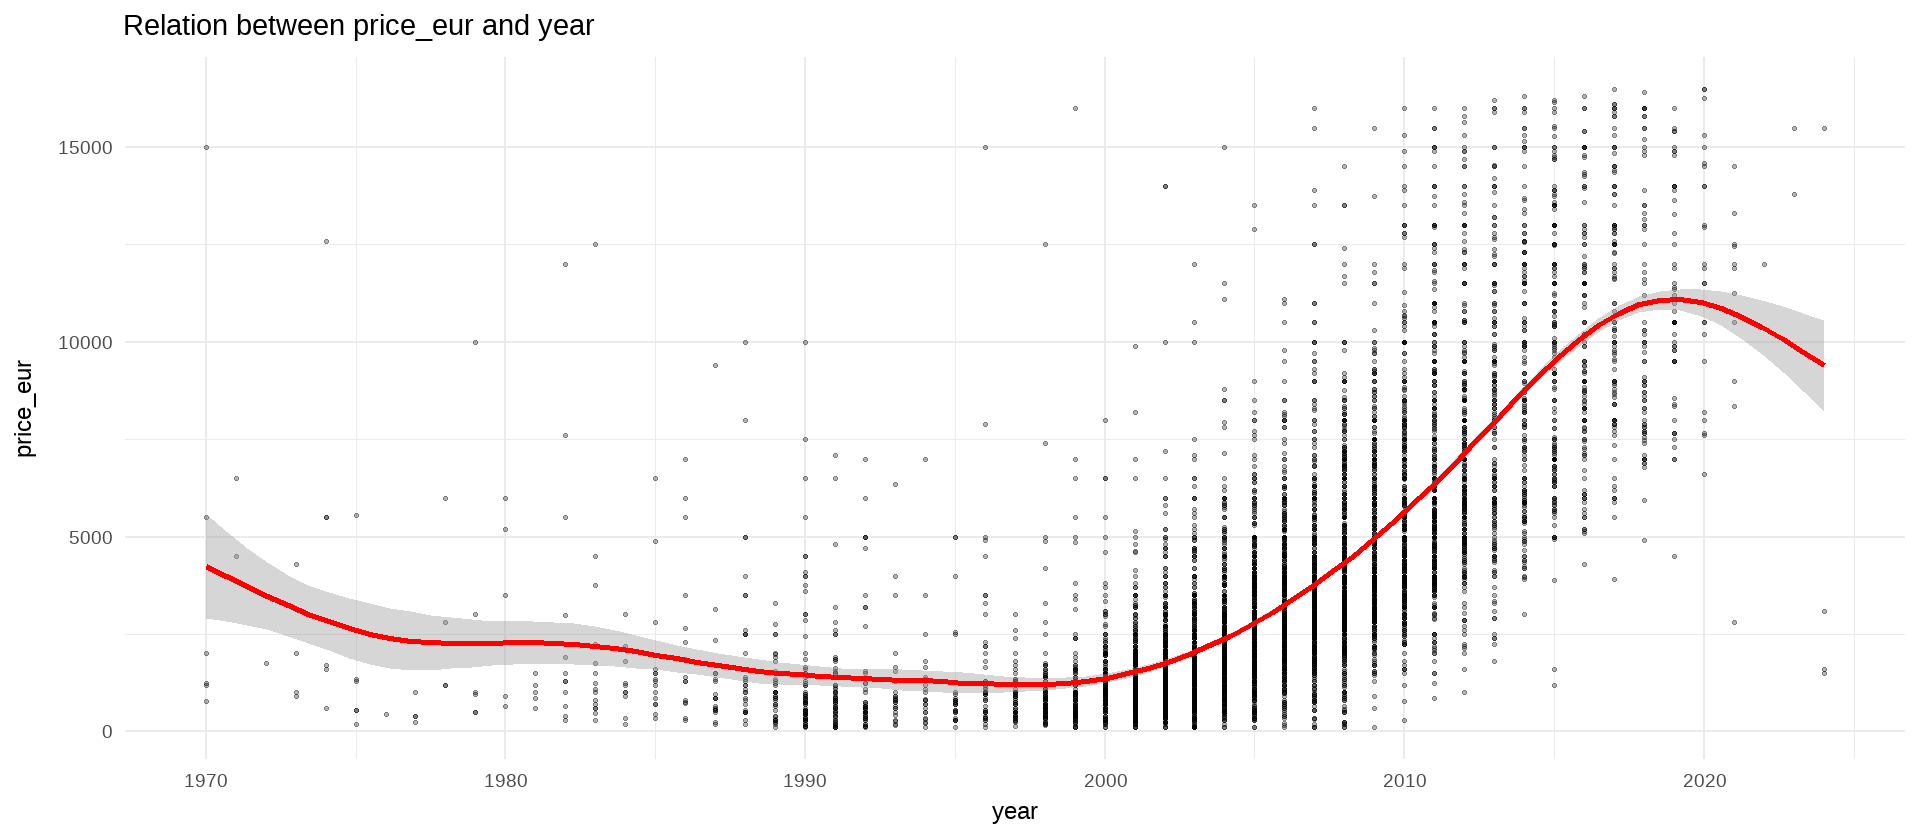

In [49]:
ggplot(cars, aes(x = year, y = price_eur)) +
  geom_point(size = 0.9, alpha = 0.3, color = "black") +
  geom_smooth(method = "gam", color = "red", se = TRUE) +
  theme_minimal(base_size = 18) +
  labs(title = "Relation between price_eur and year")

It's easily visible how much the year correlates with the car's price. It only gets lower after 2020 because cars with high prices (>16.500 EUR) were filtered. Otherwise the trendline would keep ascending. 

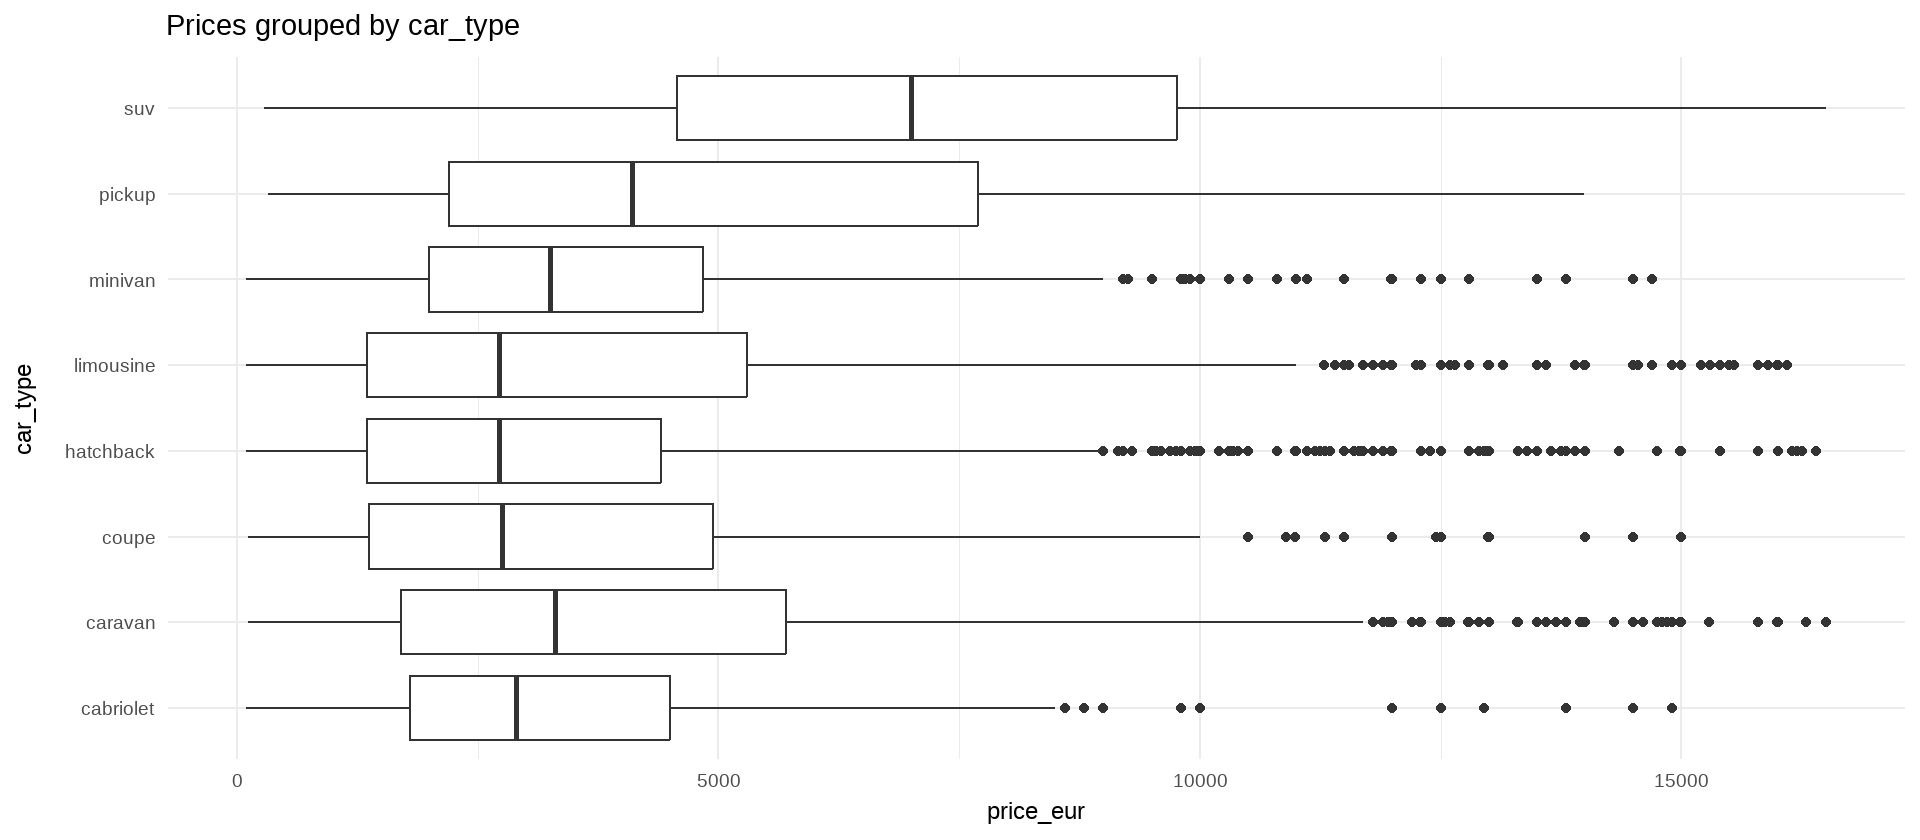

In [50]:
options(repr.plot.width = 16, repr.plot.height = 7)

ggplot(cars, aes(x = car_type, y = price_eur)) +
  geom_boxplot() +
  coord_flip() + 
  theme_minimal(base_size = 18) +
  labs(title = "Prices grouped by car_type")

SUVs have the highest prices on average, they are lot more expensive than the other car types. Pickups are the 2nd. Rest of the car types have almost the same average price.

#### Correlation diagram

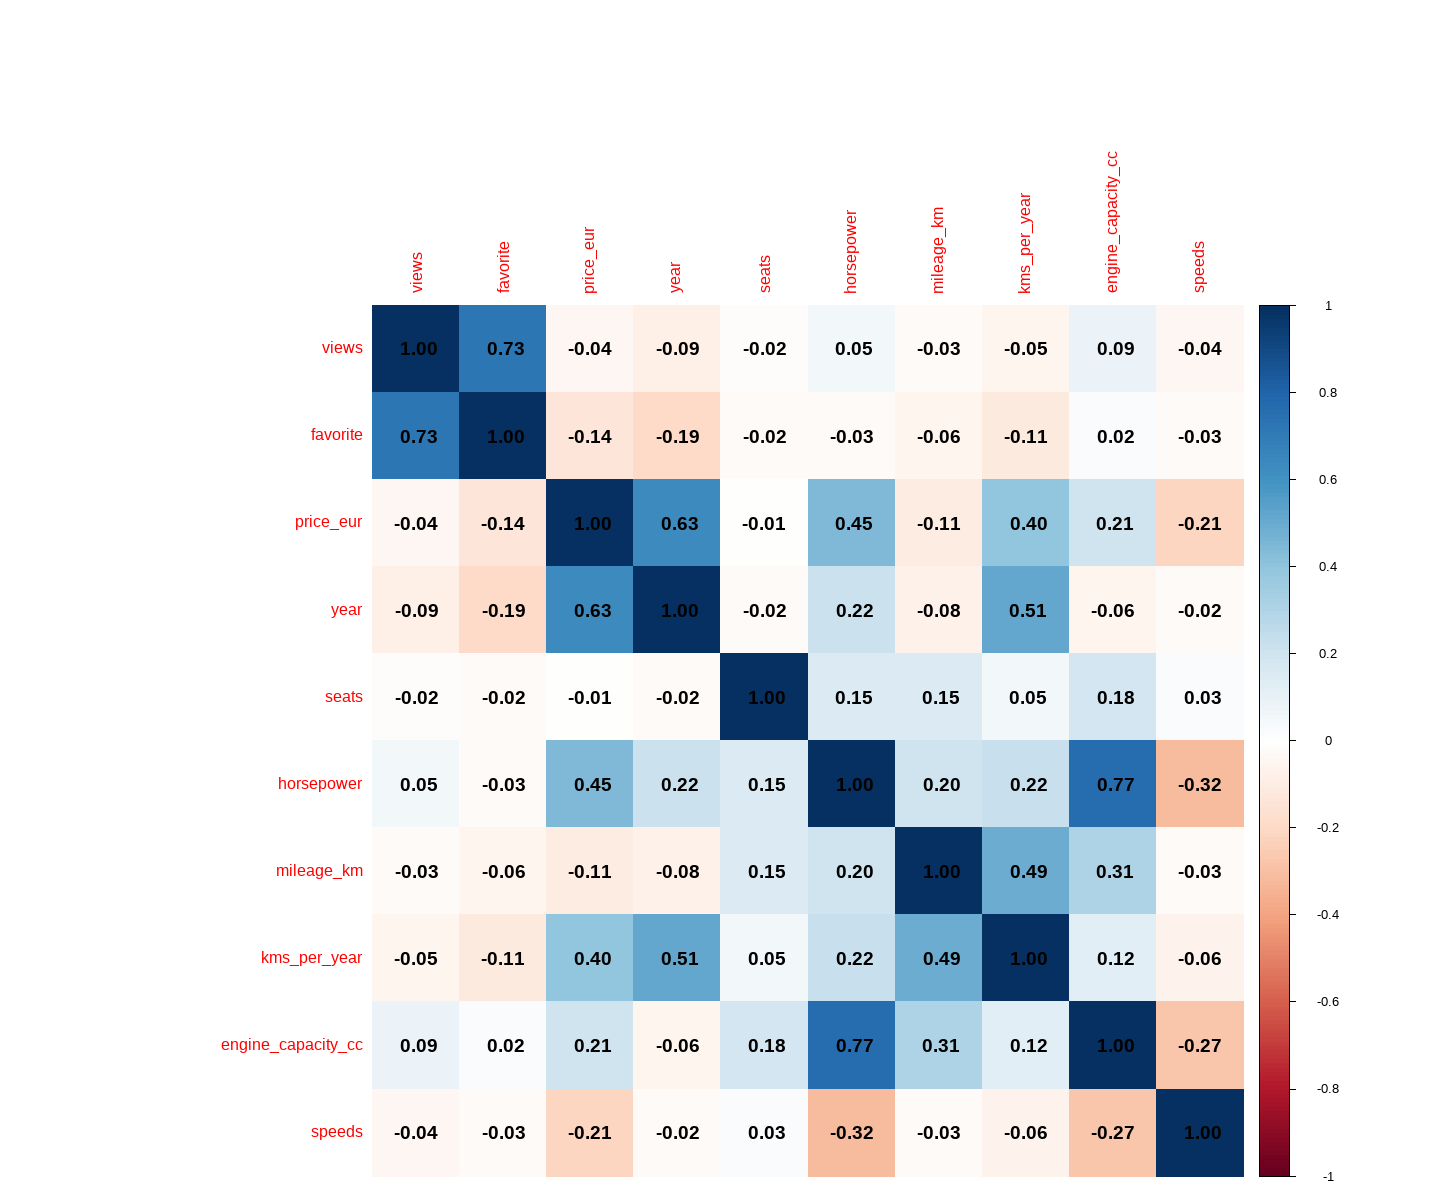

In [51]:
options(repr.plot.width = 12, repr.plot.height = 10)

num_vars <- cars %>% select(where(is.numeric)) %>% 
            select(-id, -days_passed, -emission_class)
M <- cor(num_vars)
corrplot(M, method = "color", addCoef.col = "black", number.cex = 1.2)

Price correlates mostly with the year.

Engine capacity and horsepower have a strong correlation with each other.

The posts with more views obviously have more favorites.

## Models for predicting price

#### Splitting data into training and testing sets

In [52]:
car_split <- initial_split(cars, prop = 0.8, strata = price_eur)
train_data <- training(car_split)
test_data  <- testing(car_split)

#### These columns have only a few distinct values, so they can be mapped to integers

In [53]:
cars %>%
count(ac)

cars %>%
count(gearbox)

cars %>%
count(type_of_drive)

ac,n
<chr>,<int>
automatic,3489
manual,3122
no,1376


gearbox,n
<chr>,<int>
automatic,939
manual,6974
semi-automatic,74


type_of_drive,n
<chr>,<int>
4x4,761
back,723
front,6503


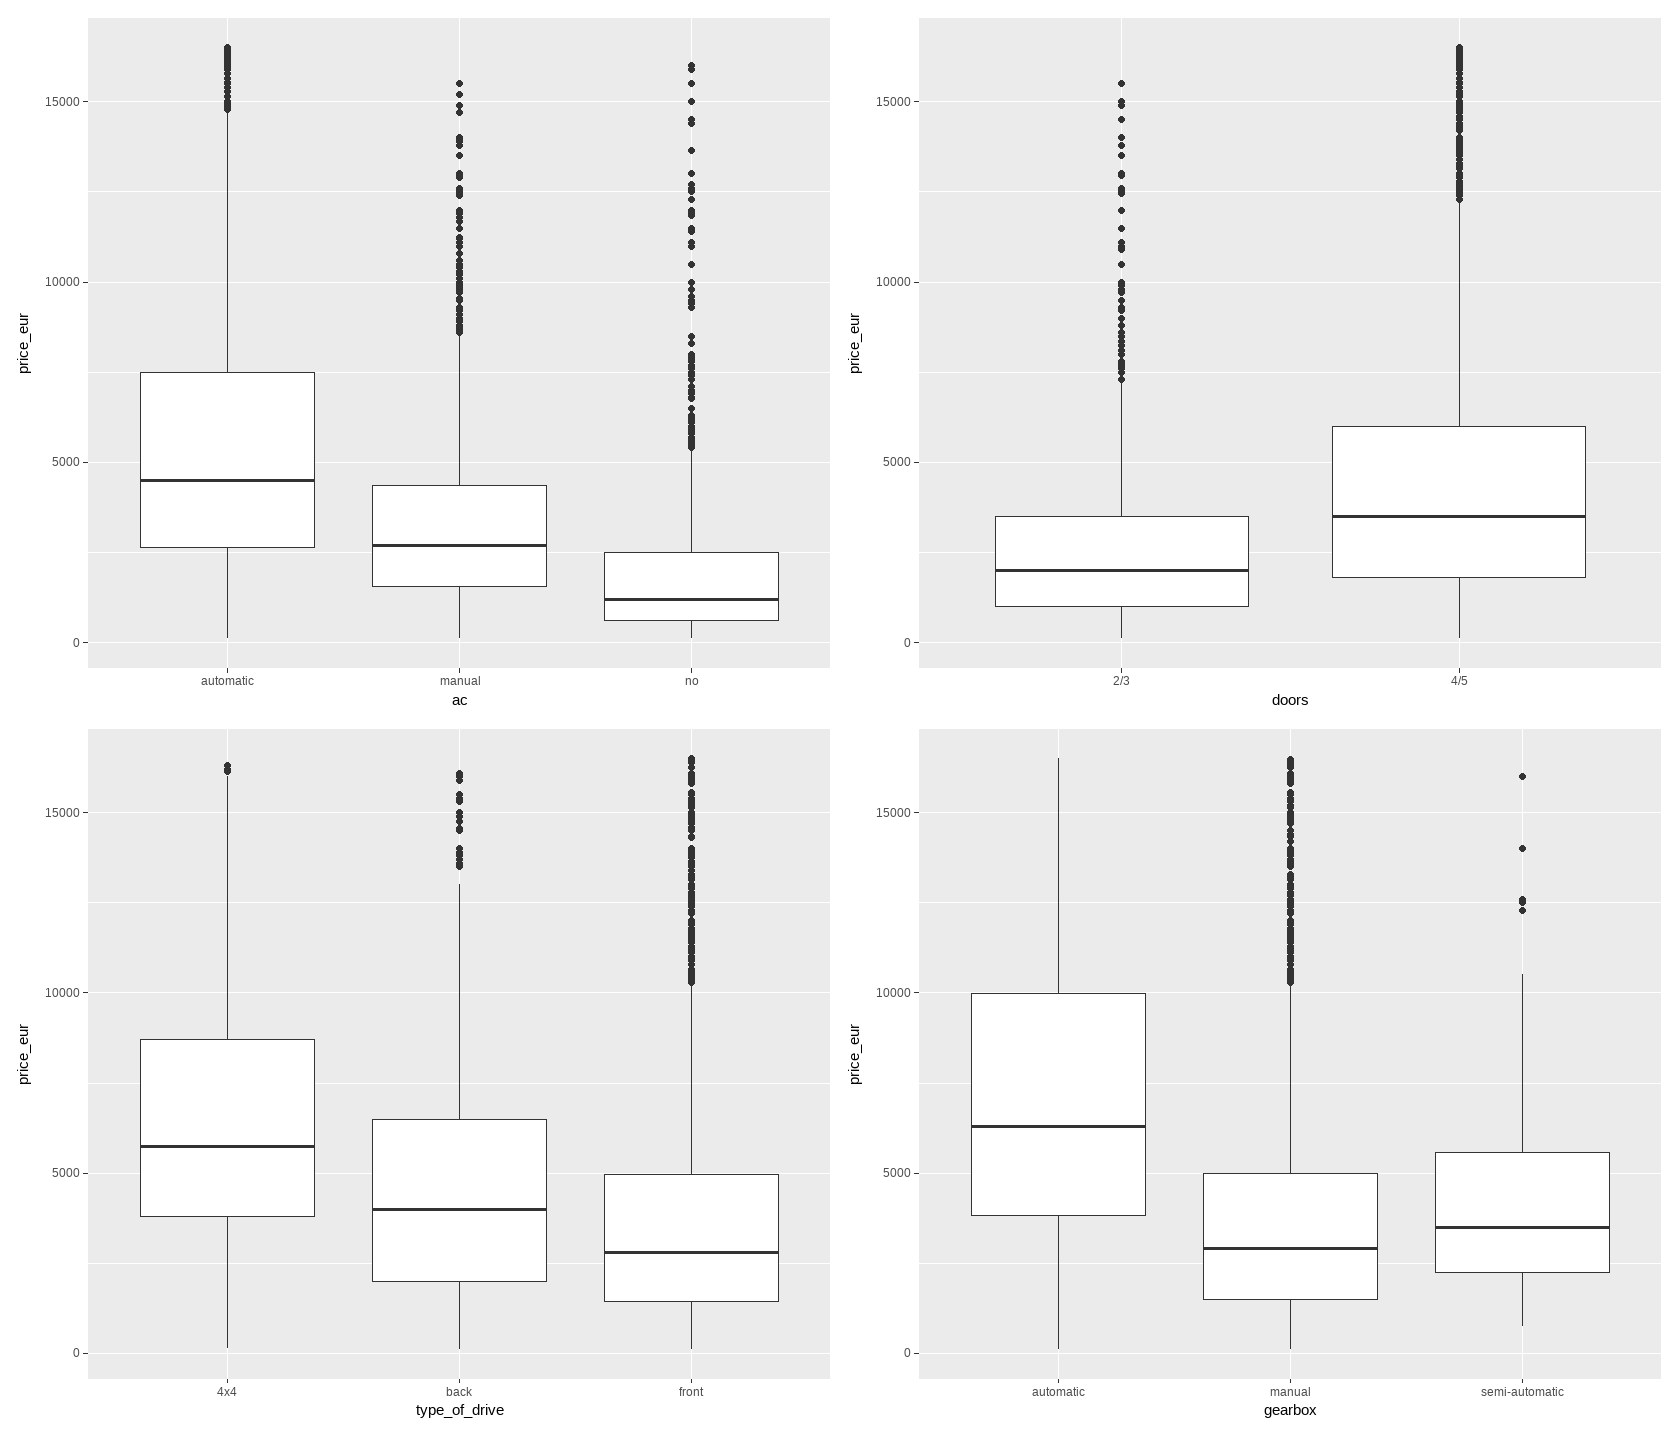

In [54]:
options(repr.plot.width = 14, repr.plot.height = 12)

p1 <- ggplot(cars, aes(x=ac, y=price_eur)) + geom_boxplot()
p2 <- ggplot(cars, aes(x=doors, y=price_eur)) + geom_boxplot()
p3 <- ggplot(cars, aes(x=type_of_drive, y=price_eur)) + geom_boxplot()
p4 <- ggplot(cars, aes(x=gearbox, y=price_eur)) + geom_boxplot()

(p1 + p2) / (p3 + p4)

#### Data engineering & creating recipe for price prediction

In [55]:
recipe_price <- recipe(price_eur ~ ., data = train_data) %>%
  # These columns are not needed for the price prediction 
  update_role(id, new_role = "ID") %>%
  update_role(views, favorite, days_passed, new_role = "info") %>%

  # Ordinal Encoding (higher number usually means higher price, e.g. automatic is usually the most expensive)
  # The boxplots visualise how the encoding should be done
  step_mutate(
    ac = factor(ac, levels = c("no", "manual", "automatic")),
    doors = factor(doors, levels = c("2/3", "4/5")),
    type_of_drive = factor(type_of_drive, levels = c("front", "back", "4x4")),
    gearbox = factor(gearbox, levels = c("manual", "semi-automatic", "automatic"))
  ) %>%
  step_integer(ac, doors, type_of_drive, gearbox, zero_based = TRUE) %>%

  # Replacing NA's in emission_class with the median
  step_impute_median(all_numeric_predictors()) %>%
  # Adding new category for rare values in test data
  step_novel(brand, color, fuel, car_type) %>%
  # Target encoding the models based on the price
  step_lencode_mixed(model, outcome = vars(price_eur)) %>%
  # Numbers instead of characters for ML
  step_dummy(brand, color, fuel, car_type) %>%
  # Dismiss data that have really low variance
  step_nzv(all_predictors()) %>%
  # Normalizing data
  step_normalize(all_numeric_predictors(), -has_role("info"), -all_outcomes())

## Model 1 - Random forest

#### Basic random forest model

In [56]:
# Creating the basic model
rf_base_spec <- rand_forest(trees = 500) %>%
  set_engine("ranger", num.threads = 12, importance="impurity") %>%
  set_mode("regression")

# Basic workflow
car_base_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(rf_base_spec)

In [57]:
base_res <- last_fit(car_base_wf, car_split)

base_predictions <- base_res %>% 
  collect_predictions()

metrics(base_predictions, truth = price_eur, estimate = .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1353.9533071
rsq,standard,0.8329816
mae,standard,873.7680738


`geom_smooth()` using formula = 'y ~ x'


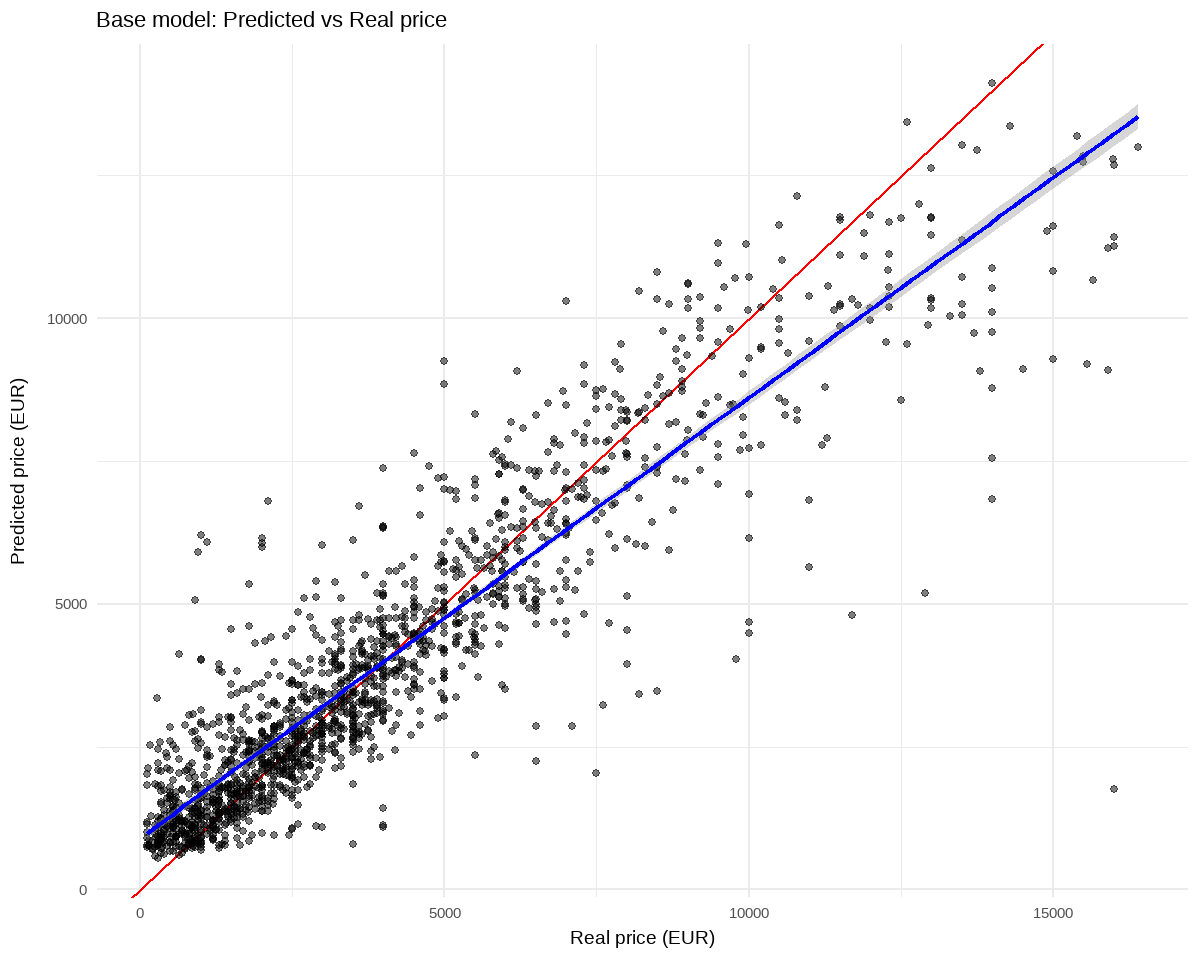

In [58]:
options(repr.plot.width = 10, repr.plot.height = 8)

base_predictions %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  theme_minimal(base_size = 14) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  labs(title = "Base model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Importance chart

,Variable,Importance
,<chr>,<dbl>
1,year,16649504508
2,model,13477720058
3,emission_class,10726120384
4,kms_per_year,5247611229
5,horsepower,4645378048
6,mileage_km,2877036808
7,engine_capacity_cc,2471592390
8,speeds,2033618324
9,ac,1884138630


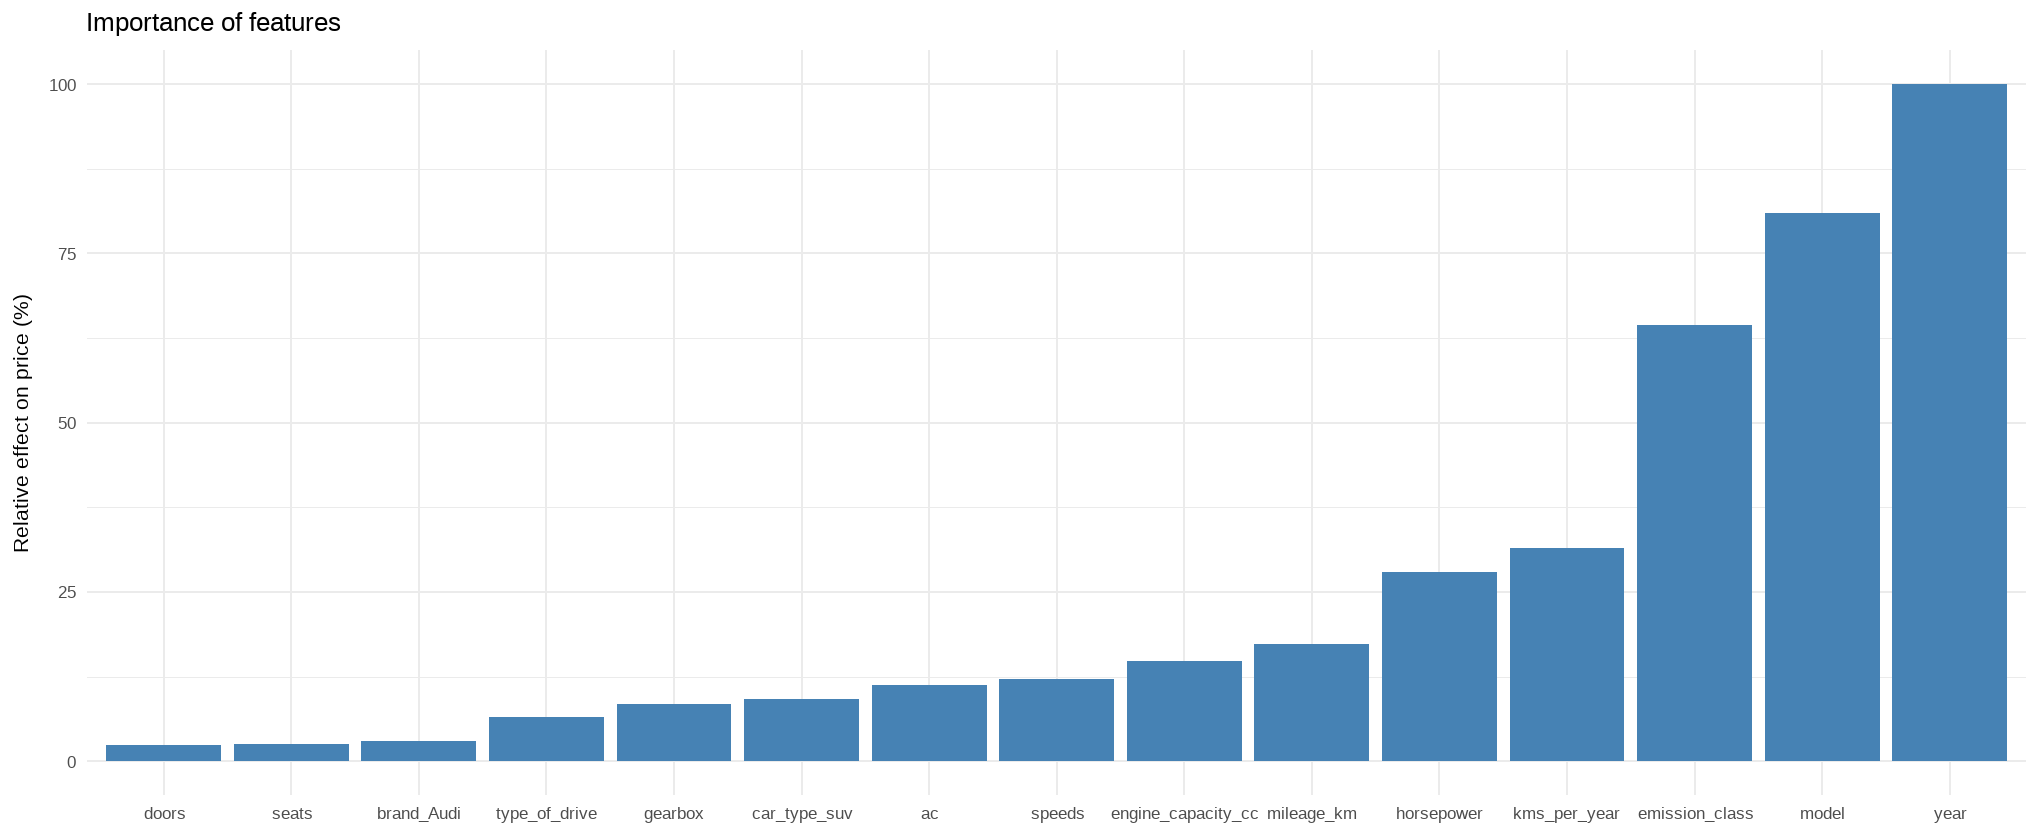

In [59]:
options(repr.plot.width = 17, repr.plot.height = 7)

base_model <- base_res %>% 
  extract_workflow() %>% 
  extract_fit_parsnip()

importance_table <- base_model %>% 
  vi(num_features = 10)

importance_table %>%
  slice_max(Importance, n = 15) %>% 
  mutate(Importance = Importance / max(Importance) * 100) %>%
  ggplot(aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_col(fill = "steelblue") +
  theme_minimal(base_size = 16) +
  labs(title = "Importance of features", x = NULL, y = "Relative effect on price (%)")

importance_table %>% as.data.frame() %>% head(10)

Year is the most important feature when predicting prices with the basic Random Forest model. Model and emission class are also important.

#### Hyperparameter tuning for Random Forest

In [60]:
rf_spec <- rand_forest(
    mtry = tune(),
    min_n = tune(),
    trees = tune()
  ) %>%
  set_engine("ranger", num.threads = 12) %>%
  set_mode("regression")

car_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(rf_spec)

In [61]:
car_folds <- vfold_cv(train_data, v = 5, strata = price_eur)

tune_res <- tune_grid(
  car_wf,
  resamples = car_folds,
  grid = 10,
  metrics = metric_set(rmse, rsq, mae),
)

i Creating pre-processing data to finalize 1 unknown parameter: "mtry"



#### Interactive visualization of the tuning

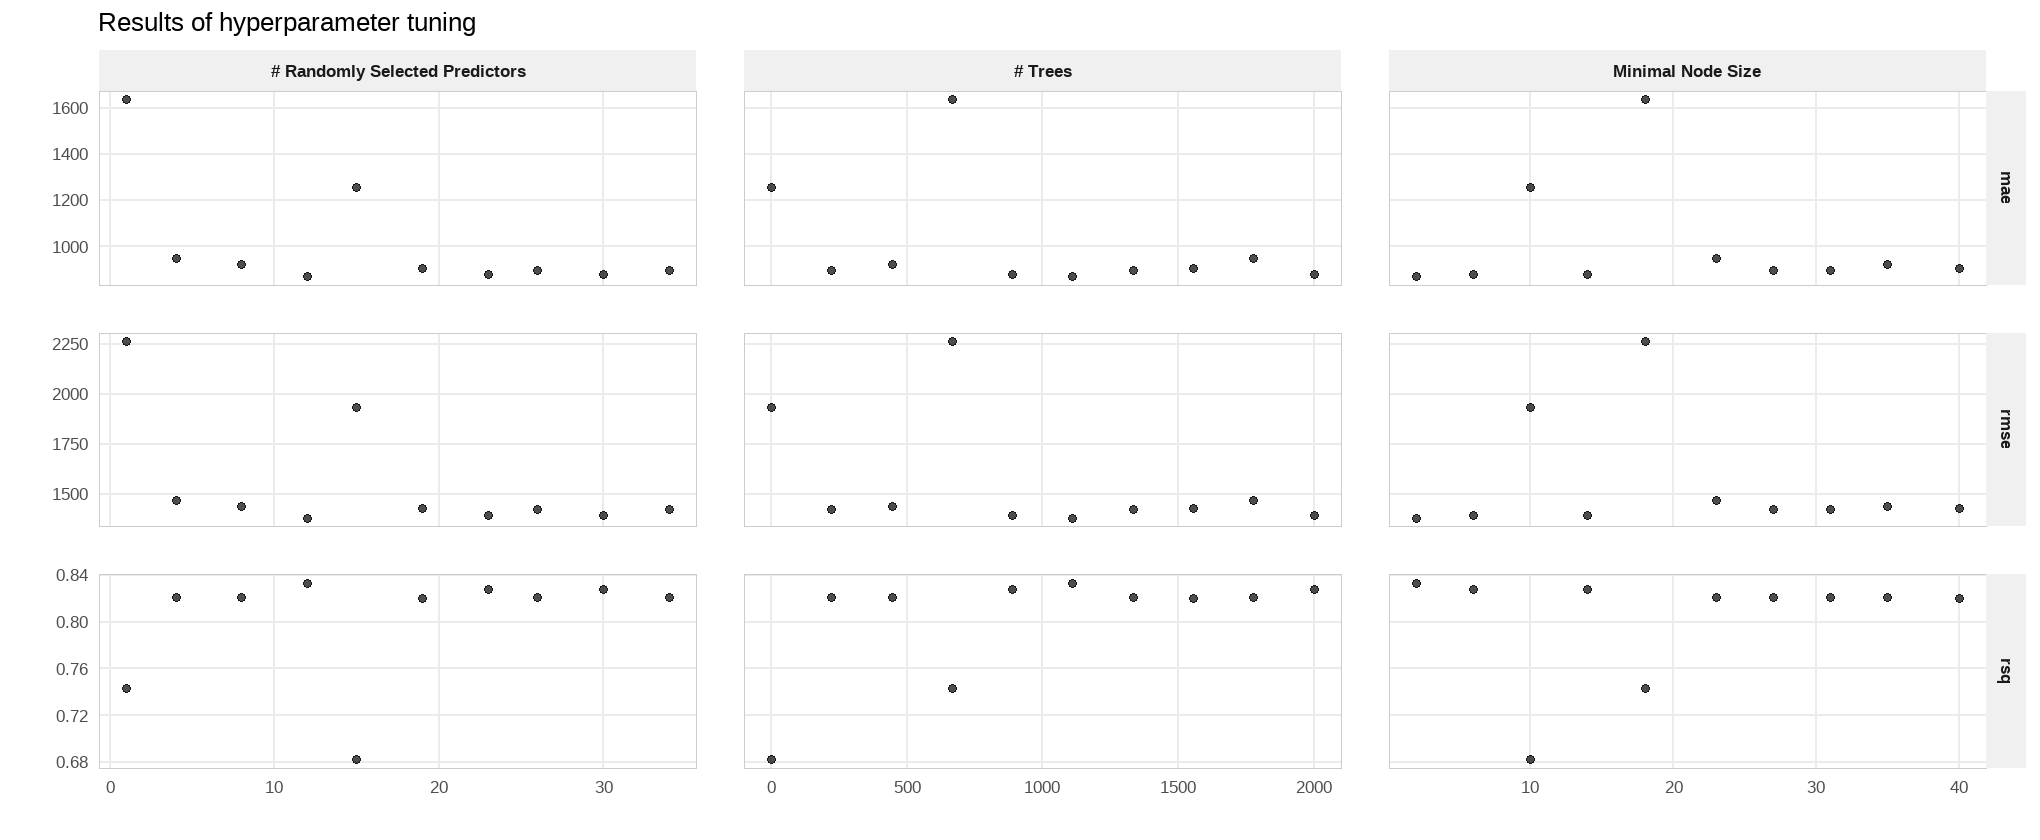

In [62]:
autoplot(tune_res) + 
  theme_minimal(base_size = 16) + 
  theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "#f0f0f0", color = NA),
    strip.text = element_text(face = "bold"),
    panel.spacing = unit(2, "lines"),
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.5)
  ) +
  labs(
    title = "Results of hyperparameter tuning"
  ) +
  scale_color_viridis_d(option = "plasma", end = 0.8)

#### Random Forest models with the best RMSE, RSQ and MAE value

In [63]:
cat("Best RMSE:\n")
best_params_rmse <- select_best(tune_res, metric = "rmse")
final_wf_rmse <- finalize_workflow(car_wf, best_params_rmse)
final_res_rmse <- last_fit(final_wf_rmse, car_split) 

final_predictions_rmse <- final_res_rmse %>%
collect_predictions()

best_params_rmse %>% as.data.frame()
metrics(final_predictions_rmse, truth = price_eur, estimate = .pred)

cat("Best RSQ:\n")
best_params_rsq <- select_best(tune_res, metric = "rsq")
final_wf_rsq <- finalize_workflow(car_wf, best_params_rsq)
final_res_rsq <- last_fit(final_wf_rsq, car_split) 

final_predictions_rsq <- final_res_rsq %>%
collect_predictions()

best_params_rsq %>% as.data.frame()
metrics(final_predictions_rsq, truth = price_eur, estimate = .pred)

cat("Best MAE:\n")
best_params_mae <- select_best(tune_res, metric = "mae")
final_wf_mae <- finalize_workflow(car_wf, best_params_mae)
final_rf_res <- last_fit(final_wf_mae, car_split)

final_predictions_rf <- final_rf_res %>%
collect_predictions()

best_params_mae %>% as.data.frame()
metrics(final_predictions_rf, truth = price_eur, estimate = .pred)

Best RMSE:


mtry,trees,min_n,.config
<int>,<int>,<int>,<chr>
12,1111,2,pre0_mod04_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1351.1755880
rsq,standard,0.8300565
mae,standard,858.6564722


Best RSQ:


mtry,trees,min_n,.config
<int>,<int>,<int>,<chr>
12,1111,2,pre0_mod04_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1351.7010437
rsq,standard,0.8299197
mae,standard,859.2008782


Best MAE:


mtry,trees,min_n,.config
<int>,<int>,<int>,<chr>
12,1111,2,pre0_mod04_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1350.4322676
rsq,standard,0.8303018
mae,standard,856.5342570


There's a chance that e.g. the best RMSE is higher (hence worse) than the RMSE value at the best RSQ because of fitting on train set vs. fitting on the 'real' data

`geom_smooth()` using formula = 'y ~ x'


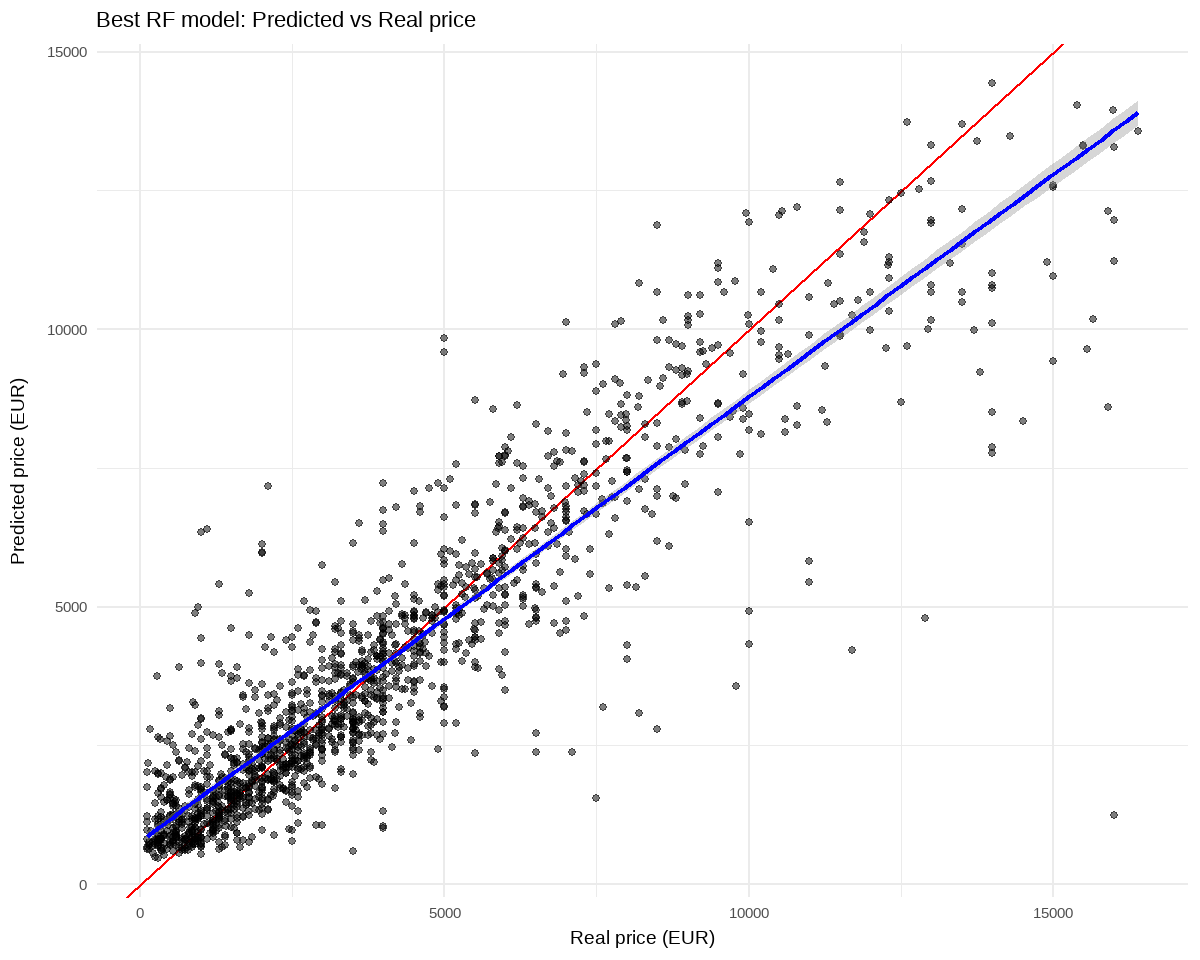

In [64]:
options(repr.plot.width = 10, repr.plot.height = 8)

final_predictions_rf %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  theme_minimal(base_size = 14) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  labs(title = "Best RF model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Worst and best predictions for Random Forest

In [65]:
predictions <- final_res_rmse %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

cat("Best predictions:\n")
best_5 %>% as.data.frame() %>% select(.pred, price_eur, .row, error)
cars[best_5$.row, ]

cat("Worst predictions:\n")
worst_5 %>% as.data.frame() %>% select(.pred, price_eur, .row, error)
cars[worst_5$.row, ]

Best predictions:


.pred,price_eur,.row,error
<dbl>,<int>,<int>,<dbl>
7200.365,7200,199,0.3650737
5998.511,5999,4953,0.4887489
3749.364,3750,255,0.6364065
7651.073,7650,324,1.0728144
2441.569,2440,486,1.5693819


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
210,32,0,Audi,A3,7,7200,2009,automatic,5,⋯,red,265000,16562,2000,front,4/5,diesel,hatchback,manual,6
5248,310,2,Peugeot,3008,5,5999,2010,manual,5,⋯,gray,212657,14177,1598,front,4/5,petrol,minivan,manual,5
270,141,1,Audi,A3,0,3750,2004,automatic,4,⋯,gray,201459,9593,1984,front,4/5,petrol,hatchback,manual,6
348,173,1,Audi,A4,7,7650,2009,automatic,5,⋯,silver,225000,14062,1968,front,4/5,diesel,caravan,manual,6
511,99,2,Audi,A4,5,2440,2002,manual,3,⋯,gray,263000,11435,1900,front,4/5,diesel,limousine,manual,5


Worst predictions:


.pred,price_eur,.row,error
<dbl>,<int>,<int>,<dbl>
1310.448,16000,7152,14689.552
4668.522,12900,1229,8231.478
4233.992,11700,3650,7466.008
8619.622,15900,3459,7280.378
3453.761,9800,3651,6346.239


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
7530,182,3,Volkswagen,Passat B3,4,16000,1999,no,3,⋯,gray,30000,1154,1998,back,4/5,diesel,caravan,manual,5
1358,93,1,Chevrolet,Suburban,14,12900,2005,automatic,3,⋯,teget,217000,10850,8100,4x4,4/5,petrol,suv,automatic,0
3906,126,4,Mercedes,S 320,21,11700,2008,automatic,NA,⋯,black,310000,18235,2998,back,4/5,diesel,limousine,automatic,0
3681,79,2,Mercedes,C 180,5,15900,2014,automatic,6,⋯,gray,234300,21300,1600,back,4/5,diesel,limousine,manual,6
3907,1133,7,Mercedes,S 320,6,9800,2006,automatic,4,⋯,teget,270000,14211,2990,front,4/5,diesel,limousine,automatic,0


## Model 2 - XGBoost

#### Basic XGBoost model

In [66]:
xgb_spec <- boost_tree() %>% 
  set_engine("xgboost") %>% 
  set_mode("regression")

xgb_workflow <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(xgb_spec)

In [67]:
xgb_fit <- xgb_workflow %>%
  fit(data = train_data)

base_results <- test_data %>%
  select(price_eur) %>%
  bind_cols(predict(xgb_fit, test_data))

metrics_results <- base_results %>%
  metrics(truth = price_eur, estimate = .pred)

metrics_results %>% as.data.frame()

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1391.7729721
rsq,standard,0.8186542
mae,standard,897.1829907


`geom_smooth()` using formula = 'y ~ x'


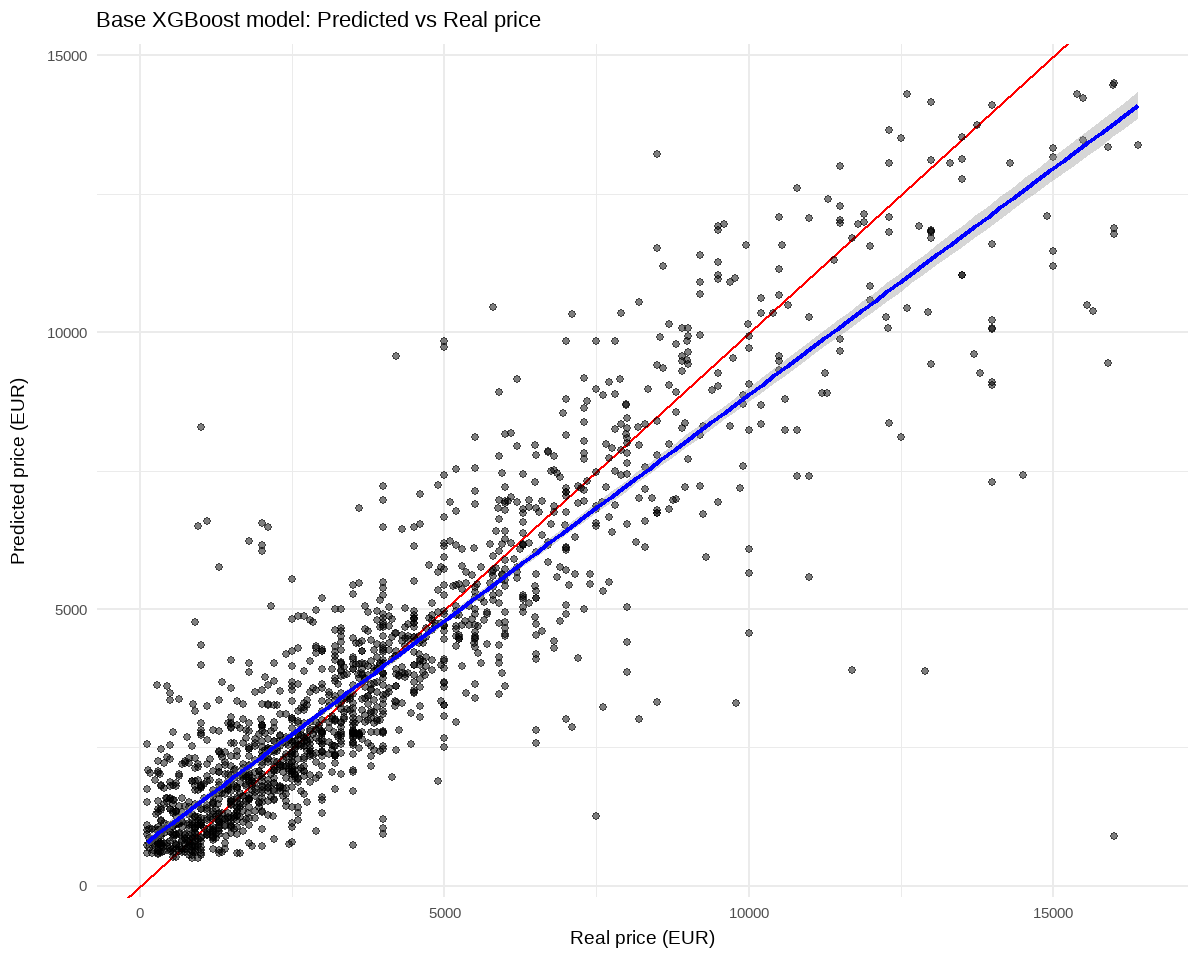

In [68]:
options(repr.plot.width = 10, repr.plot.height = 8)

base_results %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Base XGBoost model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Hyperparameter tuning for XGBoost

In [69]:
cores <- parallel::detectCores(logical = FALSE)
cl <- makePSOCKcluster(cores - 1)
registerDoParallel(cl)

car_folds <- vfold_cv(train_data, v = 5, strata = price_eur)

xgb_tune_spec <- boost_tree(
  trees = 500,
  tree_depth = tune(),
  min_n = tune(),
  learn_rate = tune(),
  loss_reduction = tune()
) %>%
  set_engine("xgboost", nthread = 12) %>%
  set_mode("regression")

xgb_tune_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(xgb_tune_spec)

xgb_rs <- tune_grid(
  xgb_tune_wf,
  resamples = car_folds,
  grid = 10,
  metrics = metric_set(rmse, rsq, mae),
  control = control_grid(save_pred = TRUE)
)

stopCluster(cl)

#### Interactive visualization of the tuning

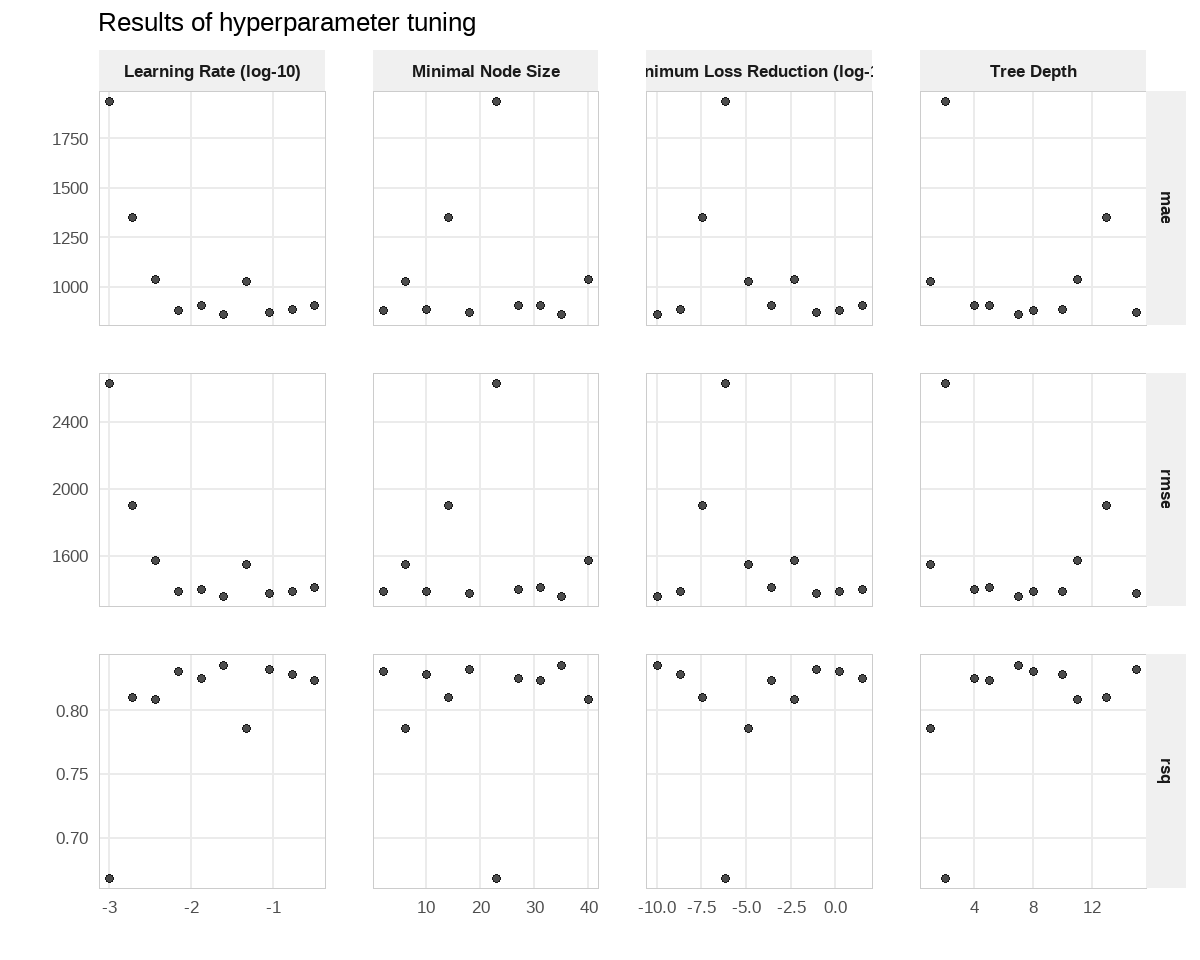

In [70]:
autoplot(xgb_rs) + 
  theme_minimal(base_size = 16) + 
  theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "#f0f0f0", color = NA),
    strip.text = element_text(face = "bold"),
    panel.spacing = unit(2, "lines"),
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.5)
  ) +
  labs(
    title = "Results of hyperparameter tuning"
  ) +
  scale_color_viridis_d(option = "plasma", end = 0.8)

#### XGBoost Models with the best RMSE, RSQ and MAE values

In [71]:
cat("Best RMSE:\n")

best_xgb_params <- select_best(xgb_rs, metric = "rmse")
final_xgb_wf <- finalize_workflow(xgb_tune_wf, best_xgb_params)
final_xgb_res <- last_fit(final_xgb_wf, car_split)

final_predictions_xgb <- final_xgb_res %>%
  collect_predictions()

best_xgb_params %>% as.data.frame()
metrics(final_predictions_xgb, truth = price_eur, estimate = .pred)

cat("Best RSQ:\n")

best_xgb_params <- select_best(xgb_rs, metric = "rsq")
final_xgb_wf <- finalize_workflow(xgb_tune_wf, best_xgb_params)
final_xgb_res <- last_fit(final_xgb_wf, car_split)

final_predictions_xgb <- final_xgb_res %>%
  collect_predictions()

best_xgb_params %>% as.data.frame()
metrics(final_predictions_xgb, truth = price_eur, estimate = .pred)

cat("Best MAE:\n")

best_xgb_params <- select_best(xgb_rs, metric = "mae")
final_xgb_wf <- finalize_workflow(xgb_tune_wf, best_xgb_params)
final_xgb_res <- last_fit(final_xgb_wf, car_split)

final_predictions_xgb <- final_xgb_res %>%
  collect_predictions()

best_xgb_params %>% as.data.frame()
metrics(final_predictions_xgb, truth = price_eur, estimate = .pred)

Best RMSE:


min_n,tree_depth,learn_rate,loss_reduction,.config
<int>,<int>,<dbl>,<dbl>,<chr>
35,7,0.02448437,1e-10,pre0_mod09_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1368.6780744
rsq,standard,0.8246414
mae,standard,868.8338257


Best RSQ:


min_n,tree_depth,learn_rate,loss_reduction,.config
<int>,<int>,<dbl>,<dbl>,<chr>
35,7,0.02448437,1e-10,pre0_mod09_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1368.6780744
rsq,standard,0.8246414
mae,standard,868.8338257


Best MAE:


min_n,tree_depth,learn_rate,loss_reduction,.config
<int>,<int>,<dbl>,<dbl>,<chr>
35,7,0.02448437,1e-10,pre0_mod09_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1368.6780744
rsq,standard,0.8246414
mae,standard,868.8338257


`geom_smooth()` using formula = 'y ~ x'


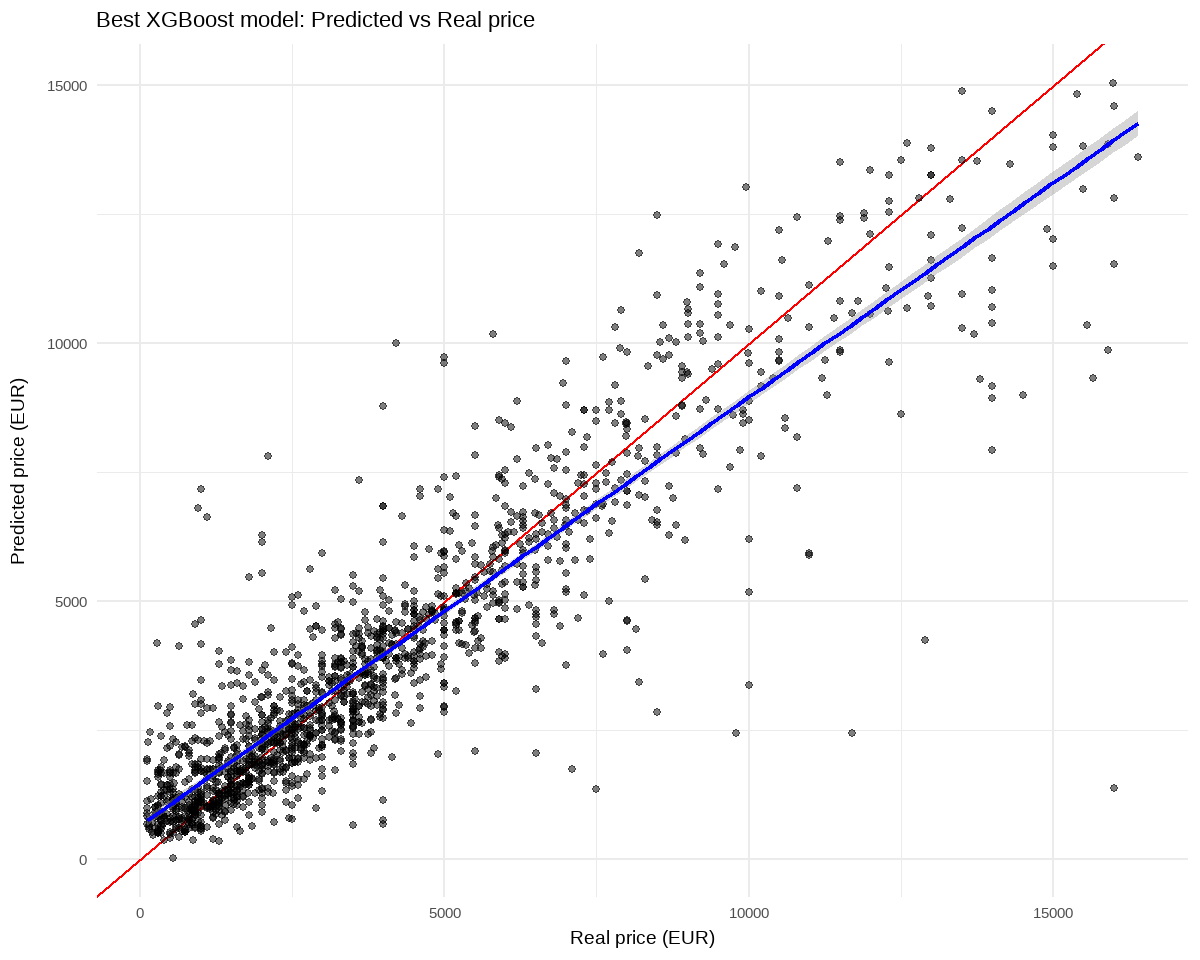

In [72]:
final_predictions_xgb %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Best XGBoost model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Worst and best predictions

In [73]:
predictions <- final_xgb_res %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

cat("Best predictions:\n")
best_5 %>% as.data.frame() %>% select(.pred, price_eur, .row, error)
cars[best_5$.row, ]

cat("Worst predictions:\n")
worst_5 %>% as.data.frame() %>% select(.pred, price_eur, .row, error)
cars[worst_5$.row, ]

Best predictions:


.pred,price_eur,.row,error
<dbl>,<int>,<int>,<dbl>
800.2833,800,7956,0.2832642
3450.6206,3450,6882,0.6206055
4799.1182,4800,424,0.8818359
1000.9894,1000,2234,0.9893799
3898.7644,3900,3445,1.2355957


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
8381,105,0,Zastava,Yugo 55,7,800,2004,no,3,⋯,red,150000,7143,1099,front,2/3,petrol,limousine,manual,4
7251,42,0,Volkswagen,Golf 5,2,3450,2005,automatic,4,⋯,gray,330000,16500,1896,front,4/5,diesel,limousine,manual,5
448,37,0,Audi,A4,14,4800,2006,automatic,4,⋯,gray,218000,11474,1968,front,4/5,diesel,caravan,automatic,0
2382,736,12,Fiat,Punto,3,1000,2001,manual,3,⋯,blue,170000,7083,1800,front,2/3,petrol,hatchback,manual,5
3667,51,0,Mercedes,B 180,7,3900,2005,manual,4,⋯,gray,185325,9266,2000,front,4/5,diesel,hatchback,manual,6


Worst predictions:


.pred,price_eur,.row,error
<dbl>,<int>,<int>,<dbl>
1367.472,16000,7152,14632.528
2451.982,11700,3650,9248.018
4246.956,12900,1229,8653.044
2449.387,9800,3651,7350.613
3364.660,10000,3655,6635.340


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
7530,182,3,Volkswagen,Passat B3,4,16000,1999,no,3,⋯,gray,30000,1154,1998,back,4/5,diesel,caravan,manual,5
3906,126,4,Mercedes,S 320,21,11700,2008,automatic,NA,⋯,black,310000,18235,2998,back,4/5,diesel,limousine,automatic,0
1358,93,1,Chevrolet,Suburban,14,12900,2005,automatic,3,⋯,teget,217000,10850,8100,4x4,4/5,petrol,suv,automatic,0
3907,1133,7,Mercedes,S 320,6,9800,2006,automatic,4,⋯,teget,270000,14211,2990,front,4/5,diesel,limousine,automatic,0
3913,118,1,Mercedes,S 350,21,10000,2003,automatic,4,⋯,gray,266000,12091,3700,back,4/5,petrol + gas,limousine,automatic,0


## Model 3 - SVM

#### Basic SVM model

In [74]:
svm_base_spec <- svm_rbf(cost = 10, margin = 0.1) %>%
  set_engine("kernlab") %>%
  set_mode("regression")

svm_base_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(svm_base_spec)

svm_base_res <- last_fit(svm_base_wf, car_split)

svm_base_predictions <- svm_base_res %>% 
  collect_predictions()

metrics(svm_base_predictions, truth = price_eur, estimate = .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1360.5199446
rsq,standard,0.8271337
mae,standard,884.7660684


`geom_smooth()` using formula = 'y ~ x'


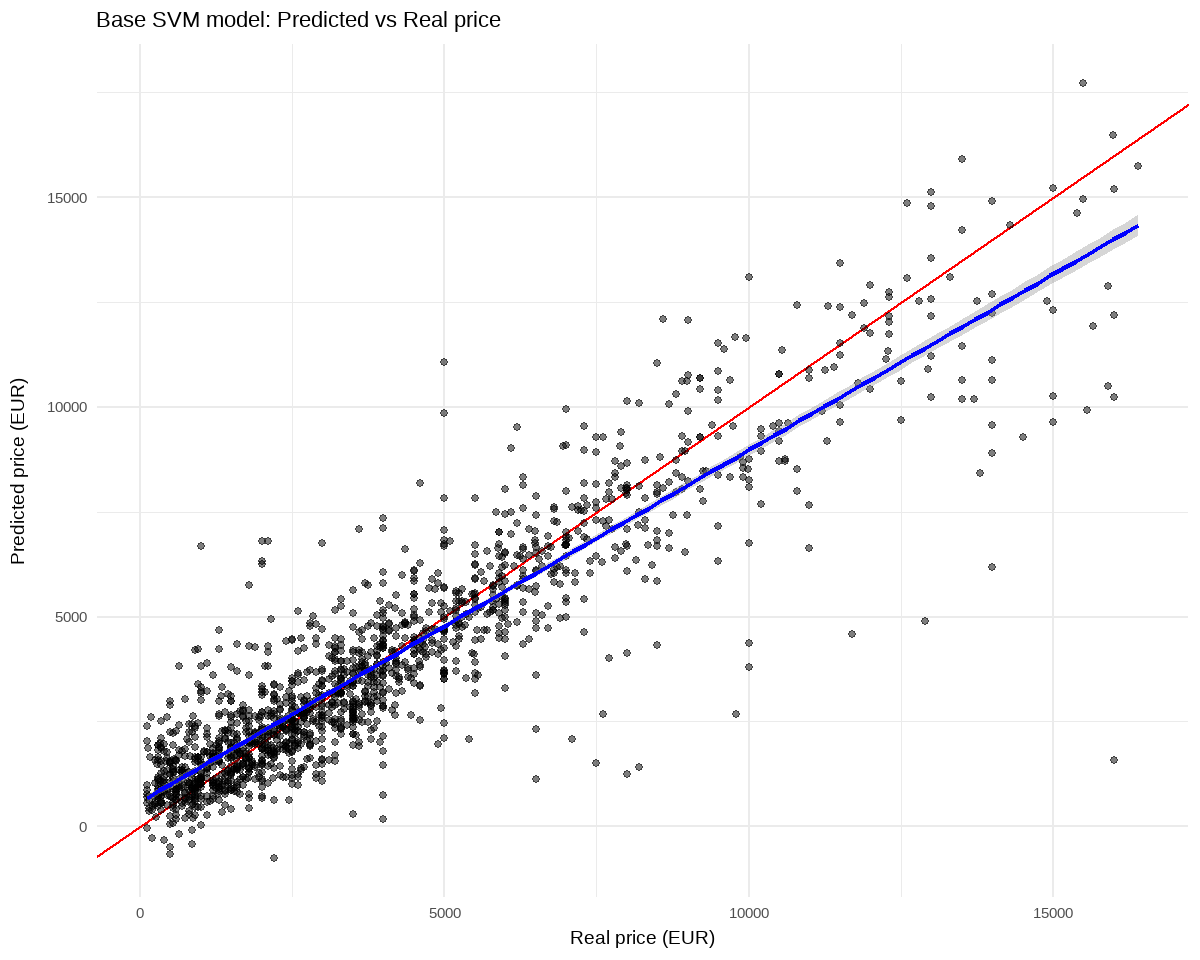

In [75]:
svm_base_predictions %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Base SVM model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Hyperparameter tuning for SVM

In [76]:
cores <- parallel::detectCores(logical = FALSE)
cl <- makePSOCKcluster(cores - 1)
registerDoParallel(cl)

svm_spec <- svm_rbf(
    cost = tune(), 
    rbf_sigma = tune(),
    margin = tune()
  ) %>%
  set_engine("kernlab") %>%
  set_mode("regression")

svm_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(svm_spec)

train_tiny <- train_data %>% slice_sample(prop = 0.3)
# Only using 30% of the training dataset, it makes the tuning lot faster

car_folds <- vfold_cv(train_tiny, v = 5, strata = price_eur)

In [77]:
svm_tune_res <- tune_grid(
  svm_wf,
  resamples = car_folds,
  grid = 10, 
  metrics = metric_set(rmse, rsq, mae),
  control = control_grid(save_pred = TRUE, parallel_over = "everything")
)

svm_tune_res %>% collect_metrics() %>% head(10)

stopCluster(cl)
registerDoSEQ()

cost,rbf_sigma,margin,.metric,.estimator,mean,n,std_err,.config
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
0.0009765625,2.154435e-07,0.08888889,mae,standard,2458.0316066,5,44.79889470,pre0_mod01_post0
0.0009765625,2.154435e-07,0.08888889,rmse,standard,3464.5028984,5,64.73190924,pre0_mod01_post0
0.0009765625,2.154435e-07,0.08888889,rsq,standard,0.6091813,5,0.02751149,pre0_mod01_post0
0.0031003927,7.742637e-02,0.11111111,mae,standard,2401.6857786,5,44.72761271,pre0_mod02_post0
0.0031003927,7.742637e-02,0.11111111,rmse,standard,3407.8699459,5,63.88314473,pre0_mod02_post0
0.0031003927,7.742637e-02,0.11111111,rsq,standard,0.4168600,5,0.01237752,pre0_mod02_post0
0.0098431332,1.668101e-08,0.17777778,mae,standard,2458.0503283,5,44.81677795,pre0_mod03_post0
0.0098431332,1.668101e-08,0.17777778,rmse,standard,3464.0972219,5,64.49710503,pre0_mod03_post0
0.0098431332,1.668101e-08,0.17777778,rsq,standard,0.6076272,5,0.02763383,pre0_mod03_post0


#### Interactive visualization of the tuning

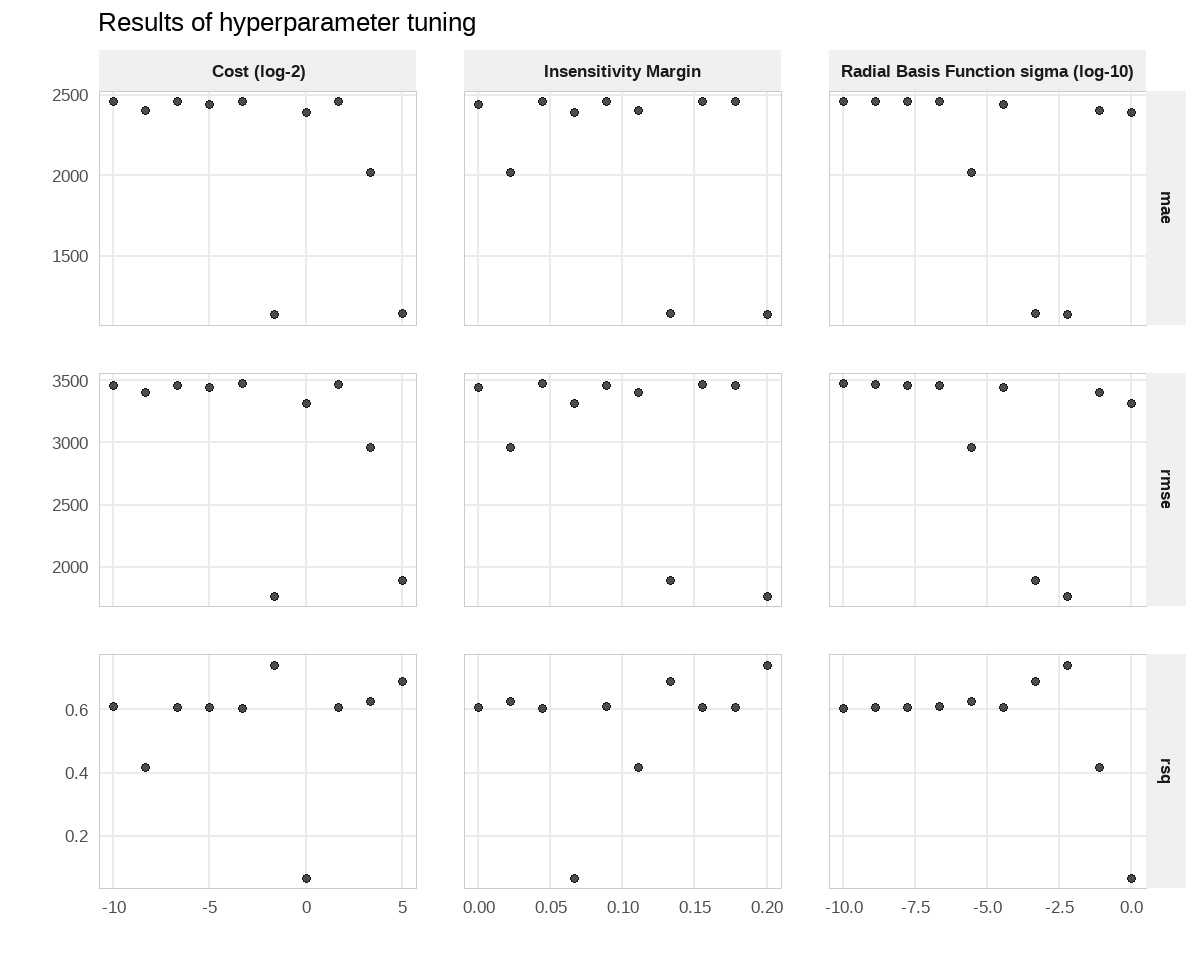

In [78]:
autoplot(svm_tune_res) +
  theme_minimal(base_size = 16) + 
  theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "#f0f0f0", color = NA),
    strip.text = element_text(face = "bold"),
    panel.spacing = unit(2, "lines"),
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.5)
  ) +
  labs(
    title = "Results of hyperparameter tuning"
  ) +
  scale_color_viridis_d(option = "plasma", end = 0.8)

#### SVM Models with the best RMSE, RSQ and MAE values

In [79]:
cat("Best RMSE:\n")

best_svm_params <- select_best(svm_tune_res, metric = "rmse")
final_svm_wf <- finalize_workflow(svm_wf, best_svm_params)
final_svm_res <- last_fit(final_svm_wf, car_split)

final_predictions_svm <- final_svm_res %>%
  collect_predictions()

best_svm_params %>% as.data.frame()
metrics(final_predictions_svm, truth = price_eur, estimate = .pred)

cat("Best RSQ:\n")
best_svm_params <- select_best(svm_tune_res, metric = "rsq")
final_svm_wf <- finalize_workflow(svm_wf, best_svm_params)
final_svm_res <- last_fit(final_svm_wf, car_split)

final_predictions_svm <- final_svm_res %>%
  collect_predictions()

best_svm_params %>% as.data.frame()
metrics(final_predictions_svm, truth = price_eur, estimate = .pred)

cat("Best MAE:\n")
best_svm_params <- select_best(svm_tune_res, metric = "mae")
final_svm_wf <- finalize_workflow(svm_wf, best_svm_params)
final_svm_res <- last_fit(final_svm_wf, car_split)

final_predictions_svm <- final_svm_res %>%
  collect_predictions()

best_svm_params %>% as.data.frame()
metrics(final_predictions_svm, truth = price_eur, estimate = .pred)

Best RMSE:


cost,rbf_sigma,margin,.config
<dbl>,<dbl>,<dbl>,<chr>
0.3149803,0.005994843,0.2,pre0_mod06_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1480.56082
rsq,standard,0.79865
mae,standard,954.24245


Best RSQ:


cost,rbf_sigma,margin,.config
<dbl>,<dbl>,<dbl>,<chr>
0.3149803,0.005994843,0.2,pre0_mod06_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1480.56082
rsq,standard,0.79865
mae,standard,954.24245


Best MAE:


cost,rbf_sigma,margin,.config
<dbl>,<dbl>,<dbl>,<chr>
0.3149803,0.005994843,0.2,pre0_mod06_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1480.56082
rsq,standard,0.79865
mae,standard,954.24245


`geom_smooth()` using formula = 'y ~ x'


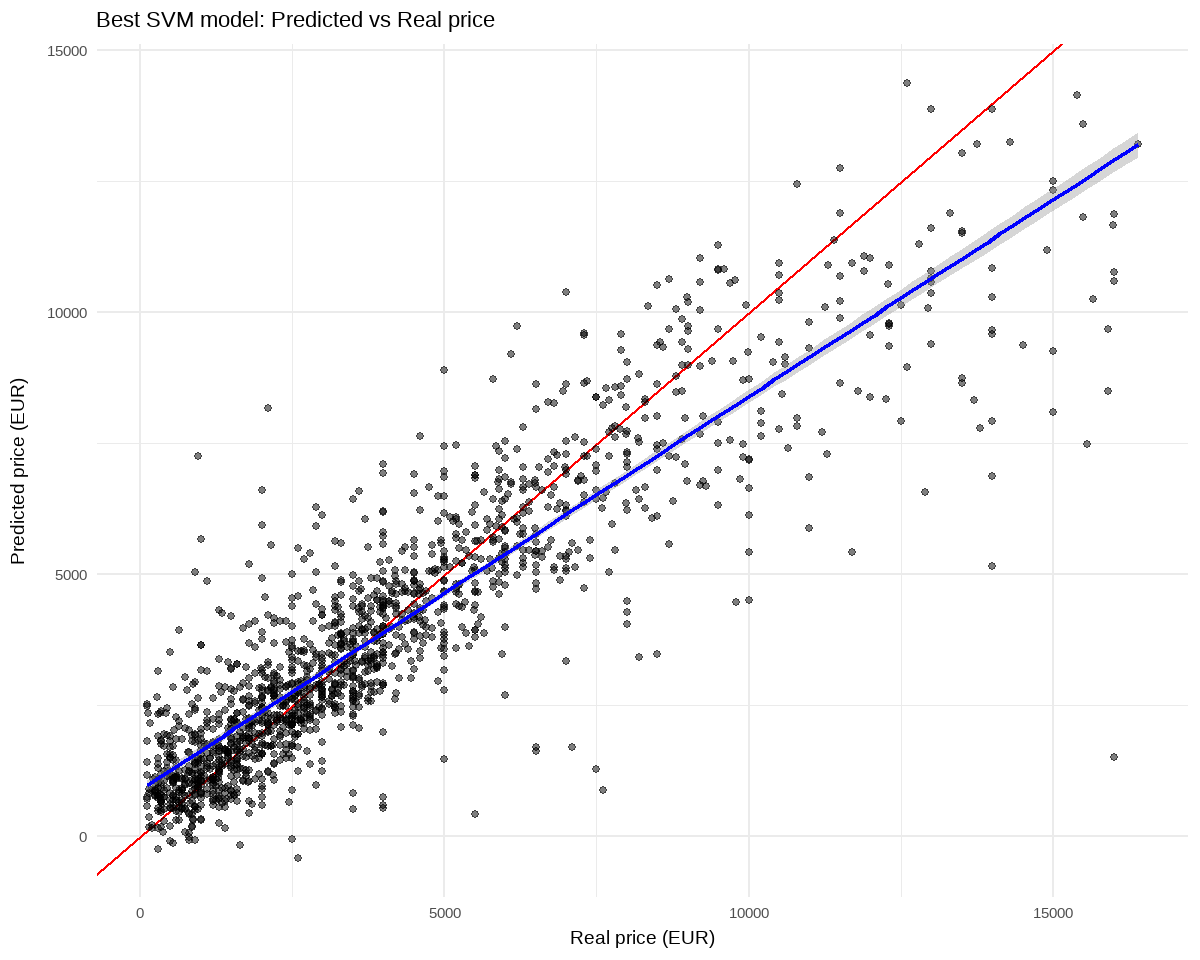

In [80]:
final_predictions_svm %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Best SVM model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Worst and best predictions for SVM model

In [81]:
predictions <- final_svm_res %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

cat("Best predictions:\n")
best_5 %>% as.data.frame() %>% select(.pred, price_eur, .row, error)
cars[best_5$.row, ]

cat("Worst predictions:\n")
worst_5 %>% as.data.frame() %>% select(.pred, price_eur, .row, error)
cars[worst_5$.row, ]

Best predictions:


.pred,price_eur,.row,error
<dbl>,<int>,<int>,<dbl>
9000.8828,9000,1392,0.8828287
1951.1205,1950,6341,1.1205293
701.8578,700,5844,1.8578239
6386.9746,6390,5779,3.0254033
903.9684,900,5151,3.9683703


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1524,192,2,Citroen,C4,21,9000,2017,automatic,6,⋯,white,189000,23625,1600,front,4/5,diesel,hatchback,automatic,0
6684,40,1,Smart,Fortwo,4,1950,2001,manual,3,⋯,gray,155245,6469,600,back,2/3,petrol,hatchback,semi-automatic,0
6166,1371,18,Renault,Scenic,7,700,2002,manual,2,⋯,gray,275000,11957,1900,front,4/5,diesel,minivan,manual,5
6098,63,0,Renault,Scenic,14,6390,2014,automatic,5,⋯,gray,307000,27909,1461,front,4/5,diesel,minivan,automatic,0
5450,220,2,Peugeot,406,21,900,1999,automatic,NA,⋯,white,280000,10769,1900,front,4/5,diesel,limousine,manual,6


Worst predictions:


.pred,price_eur,.row,error
<dbl>,<int>,<int>,<dbl>
1509.459,16000,7152,14490.541
5166.182,14000,3243,8833.818
7476.780,15550,3240,8073.220
8495.904,15900,3459,7404.096
6869.990,14000,817,7130.010


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
7530,182,3,Volkswagen,Passat B3,4,16000,1999,no,3,⋯,gray,30000,1154,1998,back,4/5,diesel,caravan,manual,5
3455,27,0,Mazda,6,1,14000,2013,automatic,NA,⋯,black,80000,6667,2000,front,4/5,petrol,limousine,manual,6
3452,296,2,Mazda,6,7,15550,2015,automatic,5,⋯,gray,229000,22900,2198,front,4/5,diesel,limousine,manual,6
3681,79,2,Mercedes,C 180,5,15900,2014,automatic,6,⋯,gray,234300,21300,1600,back,4/5,diesel,limousine,manual,6
900,49,0,BMW,318,21,14000,2013,automatic,NA,⋯,black,200000,16667,1400,back,4/5,diesel,limousine,manual,6


## Model 4 - KNN

#### Basic KNN model

In [82]:
knn_spec <- nearest_neighbor(neighbors = 15) %>%
  set_engine("kknn") %>%
  set_mode("regression")

knn_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(knn_spec)

metrics <- metric_set(rmse, rsq, mae)

knn_res <- last_fit(knn_wf, car_split)

knn_base_pred <- knn_res %>% 
  collect_predictions()

metrics(base_predictions, truth = price_eur, estimate = .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1353.9533071
rsq,standard,0.8329816
mae,standard,873.7680738


`geom_smooth()` using formula = 'y ~ x'


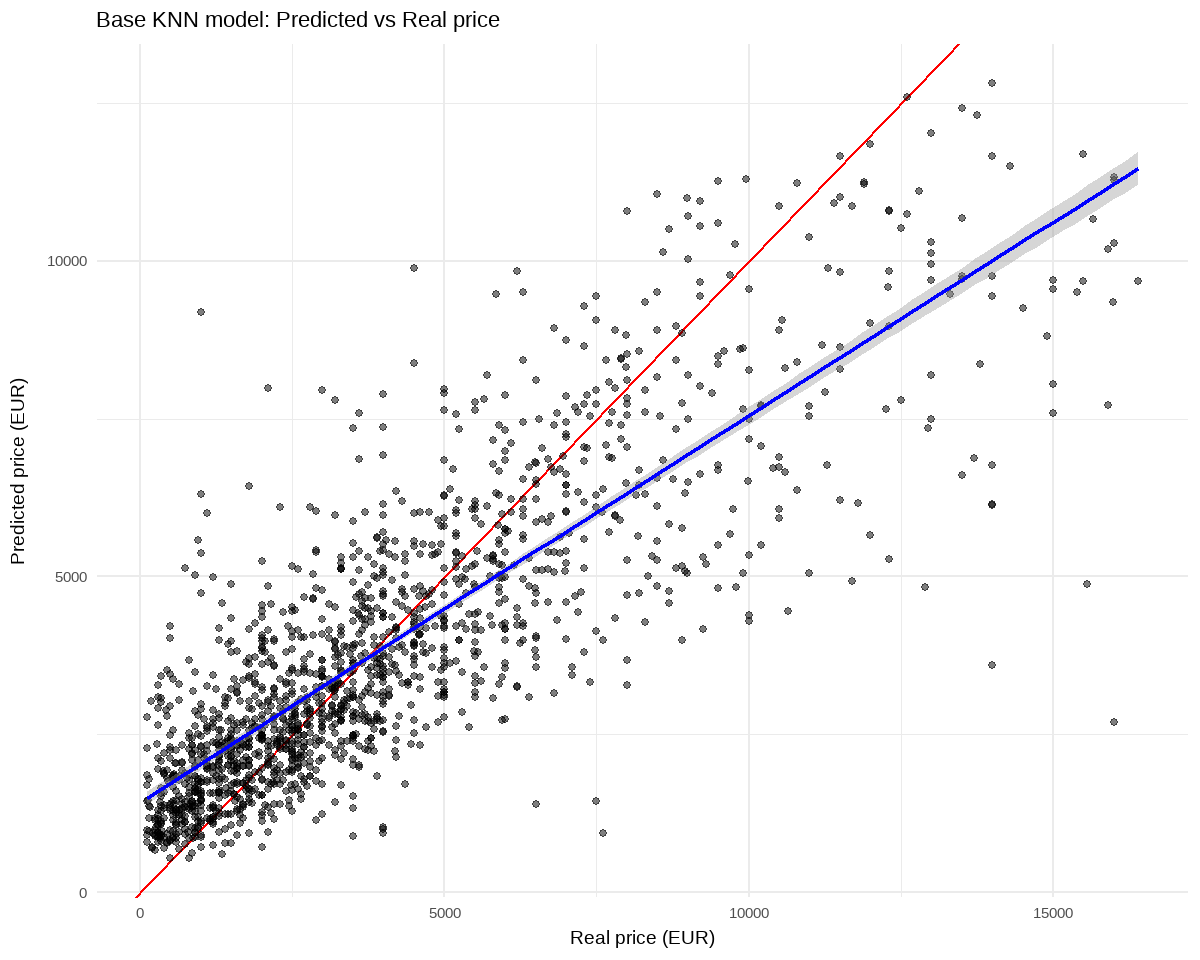

In [83]:
knn_base_pred %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Base KNN model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Hyperparameter tuning for KNN

In [84]:
cores <- parallel::detectCores(logical = FALSE)
cl <- makePSOCKcluster(cores - 1)
registerDoParallel(cl)

knn_spec <- nearest_neighbor(
    neighbors = tune(),
    weight_func = tune(),
    dist_power = tune()
  ) %>%
  set_engine("kknn") %>%
  set_mode("regression")

knn_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(knn_spec)

train_tiny <- train_data %>% slice_sample(prop = 0.3)
car_folds <- vfold_cv(train_tiny, v = 5, strata = price_eur)

In [85]:
knn_tune_res <- tune_grid(
  knn_wf,
  resamples = car_folds,
  grid = 10,
  metrics = metric_set(rmse, rsq, mae),
  control = control_grid(save_pred = TRUE, parallel_over = "everything")
)

knn_tune_res %>% collect_metrics() %>% head(10)

stopCluster(cl)

neighbors,weight_func,dist_power,.metric,.estimator,mean,n,std_err,.config
<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,gaussian,0.9444444,mae,standard,1611.8656514,5,47.72393837,pre0_mod01_post0
1,gaussian,0.9444444,rmse,standard,2420.4856372,5,85.51265001,pre0_mod01_post0
1,gaussian,0.9444444,rsq,standard,0.5202898,5,0.02864241,pre0_mod01_post0
2,triangular,1.1555556,mae,standard,1486.0185941,5,28.19508287,pre0_mod02_post0
2,triangular,1.1555556,rmse,standard,2219.0177691,5,61.27969157,pre0_mod02_post0
2,triangular,1.1555556,rsq,standard,0.5722487,5,0.02058940,pre0_mod02_post0
4,epanechnikov,1.7888889,mae,standard,1454.6748263,5,39.19172597,pre0_mod03_post0
4,epanechnikov,1.7888889,rmse,standard,2138.1434382,5,71.97190050,pre0_mod03_post0
4,epanechnikov,1.7888889,rsq,standard,0.5908708,5,0.02624387,pre0_mod03_post0


#### Interactive visualization of the tuning

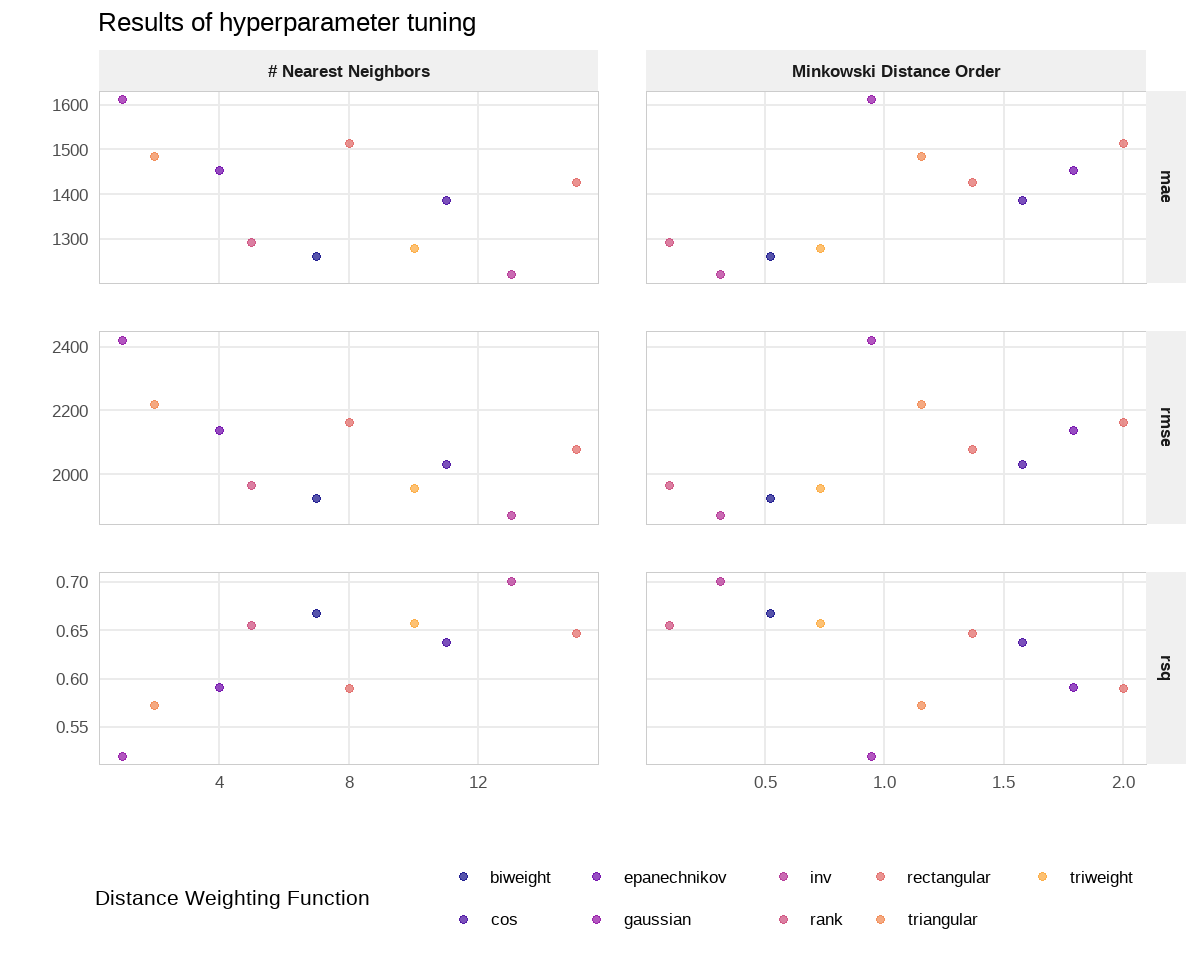

In [86]:
autoplot(knn_tune_res) +
  theme_minimal(base_size = 16) + 
  theme(
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "#f0f0f0", color = NA),
    strip.text = element_text(face = "bold"),
    panel.spacing = unit(2, "lines"),
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.5)
  ) +
  labs(
    title = "Results of hyperparameter tuning"
  ) +
  scale_color_viridis_d(option = "plasma", end = 0.8)

#### KNN Model with the best MAE value

In [87]:
best_knn <- knn_tune_res %>% select_best(metric = "mae")

final_knn_wf <- knn_wf %>% finalize_workflow(best_knn)

final_knn_res <- last_fit(final_knn_wf, car_split)

final_predictions_knn <- final_knn_res %>%
  collect_predictions()

best_knn %>% as.data.frame()
metrics(final_predictions_knn, truth = price_eur, estimate = .pred)

neighbors,weight_func,dist_power,.config
<int>,<chr>,<dbl>,<chr>
13,inv,0.3111111,pre0_mod09_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1626.8858640
rsq,standard,0.7617983
mae,standard,1061.5005876


`geom_smooth()` using formula = 'y ~ x'


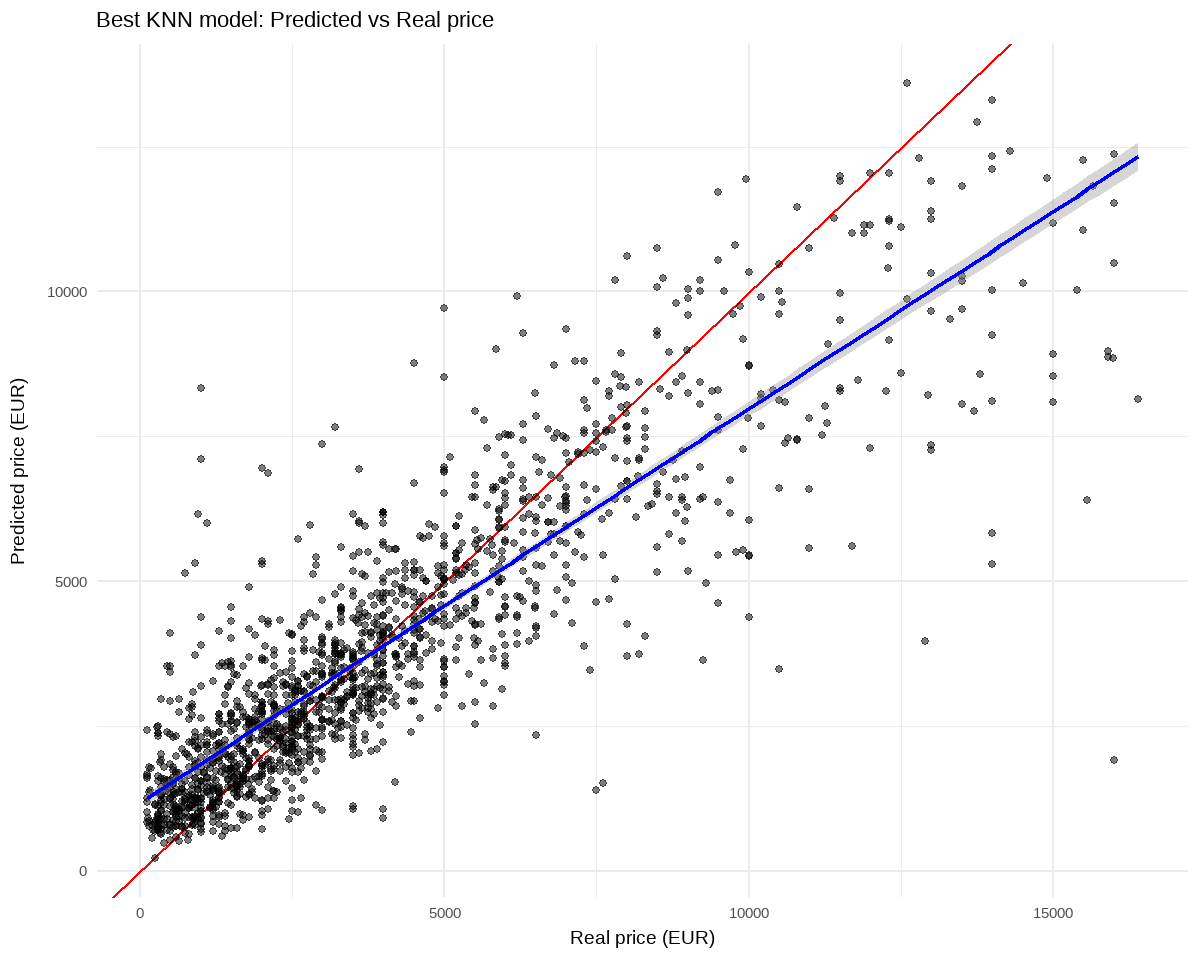

In [88]:
final_predictions_knn %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Best KNN model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Worst and best predictions for KNN model

In [89]:
predictions <- final_knn_res %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

cat("Best predictions:\n")
best_5 %>% as.data.frame() %>% select(.pred, price_eur, .row, error)
cars[best_5$.row, ]

cat("Worst predictions:\n")
worst_5 %>% as.data.frame() %>% select(.pred, price_eur, .row, error)
cars[worst_5$.row, ]

Best predictions:


.pred,price_eur,.row,error
<dbl>,<int>,<int>,<dbl>
3199.992,3200,494,0.008067401
7199.990,7200,199,0.010064436
5549.986,5550,7319,0.013837193
1350.014,1350,1668,0.014100325
8990.018,8990,7092,0.018380067


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
520,14,0,Audi,A4,14,3200,2002,automatic,3,⋯,gray,245000,10652,1896,front,4/5,diesel,caravan,manual,5
210,32,0,Audi,A3,7,7200,2009,automatic,5,⋯,red,265000,16562,2000,front,4/5,diesel,hatchback,manual,6
7698,3,0,Volkswagen,Passat B6,7,5550,2006,no,4,⋯,teget,312000,16421,1968,front,4/5,diesel,limousine,automatic,0
1807,10,0,Citroen,Xsara Picasso,1,1350,2001,manual,4,⋯,black,400000,16667,1800,front,4/5,petrol + gas,minivan,manual,5
7466,71,0,Volkswagen,Golf 7,14,8990,2013,automatic,5,⋯,gray,194000,16167,1596,front,4/5,diesel,hatchback,automatic,0


Worst predictions:


.pred,price_eur,.row,error
<dbl>,<int>,<int>,<dbl>
1905.795,16000,7152,14094.205
6398.419,15550,3240,9151.581
3966.314,12900,1229,8933.686
5293.070,14000,3243,8706.930
8145.060,16400,6270,8254.940


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
7530,182,3,Volkswagen,Passat B3,4,16000,1999,no,3,⋯,gray,30000,1154,1998,back,4/5,diesel,caravan,manual,5
3452,296,2,Mazda,6,7,15550,2015,automatic,5,⋯,gray,229000,22900,2198,front,4/5,diesel,limousine,manual,6
1358,93,1,Chevrolet,Suburban,14,12900,2005,automatic,3,⋯,teget,217000,10850,8100,4x4,4/5,petrol,suv,automatic,0
3455,27,0,Mazda,6,1,14000,2013,automatic,NA,⋯,black,80000,6667,2000,front,4/5,petrol,limousine,manual,6
6607,57,0,Skoda,Superb,21,16400,2018,automatic,6,⋯,gray,206000,29429,1986,front,4/5,diesel,hatchback,manual,6


## Comparing the models

#### Comparing RMSE, RSQ and MAE values

In [90]:
prediction_list <- list(
  RandomForest = final_predictions_rf,
  XGBoost = final_predictions_xgb,
  SVM = final_predictions_svm,
  KNN = final_predictions_knn
)

comparison_table <- prediction_list %>%
  map_df(~ metrics(.x, truth = price_eur, estimate = .pred), .id = "model") %>%
  select(model, .metric, .estimate) %>%
  pivot_wider(names_from = .metric, values_from = .estimate) %>%
  arrange(mae)

comparison_table %>% as.data.frame()

model,rmse,rsq,mae
<chr>,<dbl>,<dbl>,<dbl>
RandomForest,1350.432,0.8303018,856.5343
XGBoost,1368.678,0.8246414,868.8338
SVM,1480.561,0.7986500,954.2424
KNN,1626.886,0.7617983,1061.5006


XGBoost and Random Forest tends to be the best model for our price prediction. They are really close, their performance can change based on the tuning. 

SVM is visibly worse than the previous two models, but still better than the KNN which is far away from the results of XGBoost and RF. 

SVM and KNN are also working slower.

`geom_smooth()` using formula = 'y ~ x'


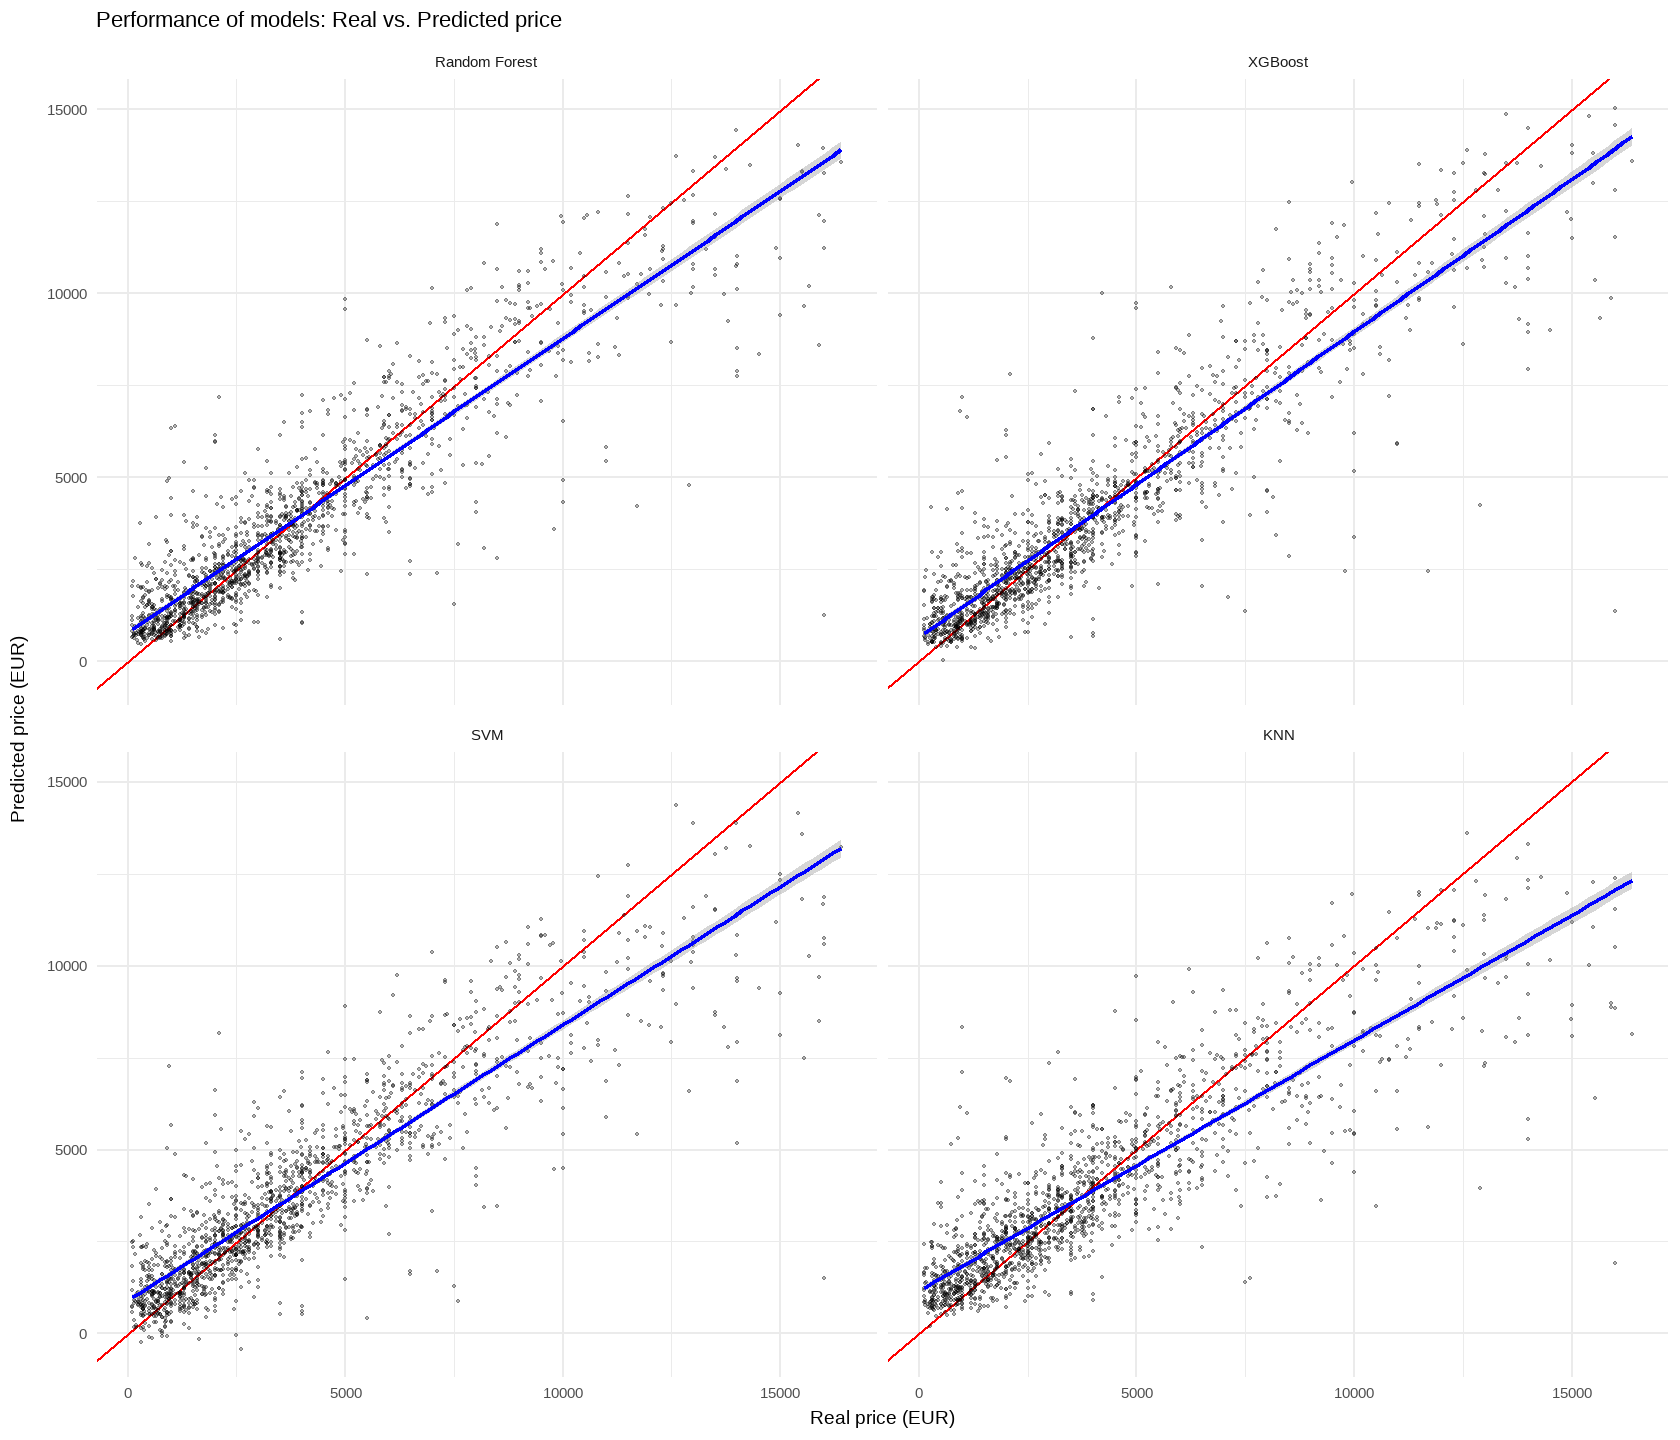

In [91]:
options(repr.plot.width = 14, repr.plot.height = 12)

all_preds <- bind_rows(
  final_predictions_rf  %>% mutate(model = "Random Forest"),
  final_predictions_xgb %>% mutate(model = "XGBoost"),
  final_predictions_svm %>% mutate(model = "SVM"),
  final_predictions_knn %>% mutate(model = "KNN")
) %>%
  mutate(model = factor(model, levels = c("Random Forest", "XGBoost", "SVM", "KNN")))

ggplot(all_preds, aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.3, size = 0.8) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  facet_wrap(~model) +
  theme_minimal(base_size = 14) +
  labs(title = "Performance of models: Real vs. Predicted price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

It's visible how RF and XGBoost predictions are a lot closer to the real price than SVM and KNN.

KNN handles the outliers worse than the other models

#### Error distribution

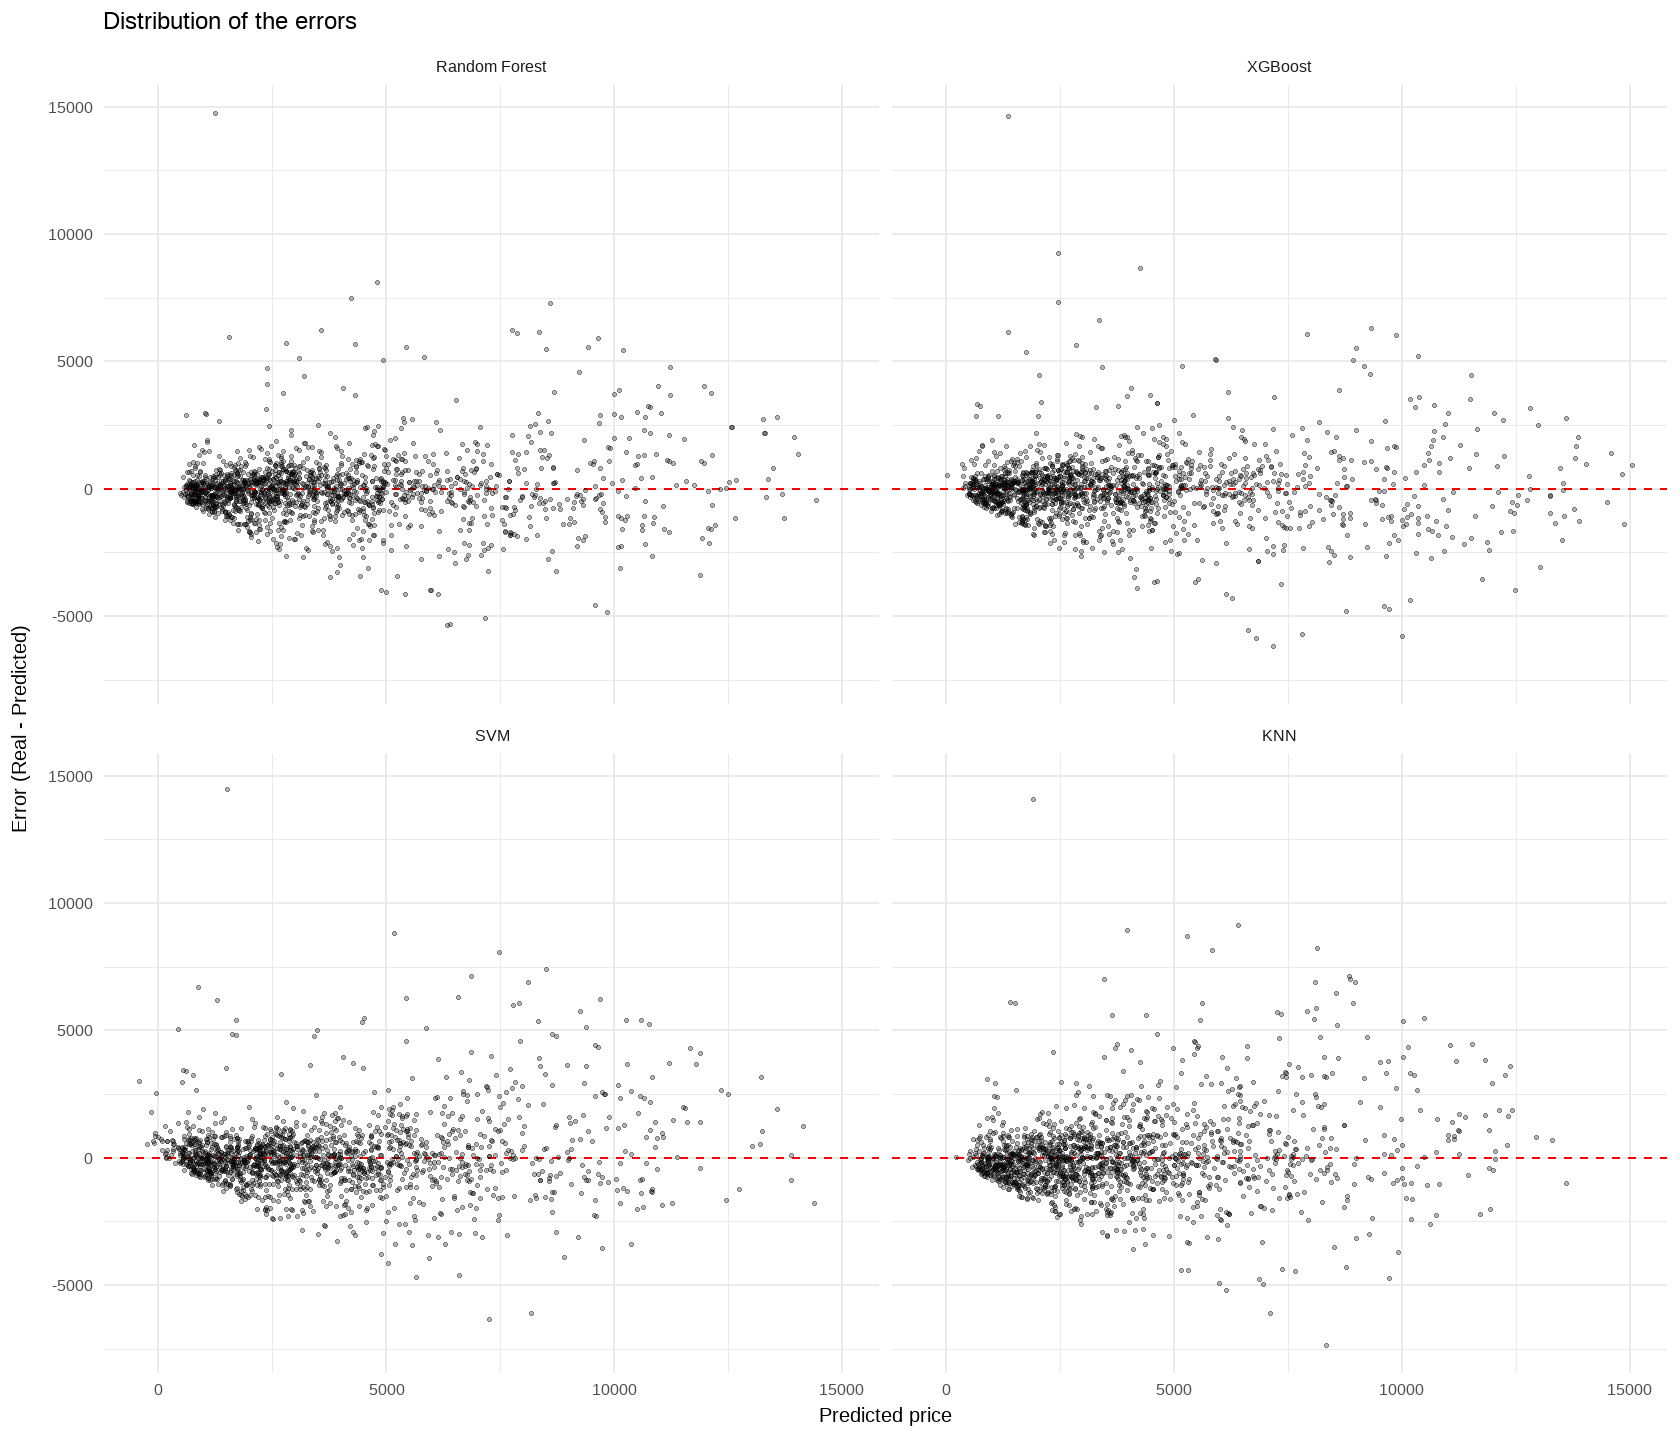

In [92]:
all_preds %>%
  mutate(residual = price_eur - .pred) %>%
  ggplot(aes(x = .pred, y = residual)) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  geom_point(alpha = 0.3, size = 0.9) +
  facet_wrap(~model) +
  theme_minimal(base_size = 15) +
  labs(title = "Distribution of the errors",
       x = "Predicted price", y = "Error (Real - Predicted)")

The error distribution spreads out more at SVM and KNN in a V shape

#### Selecting random cars and comparing the models' prediction

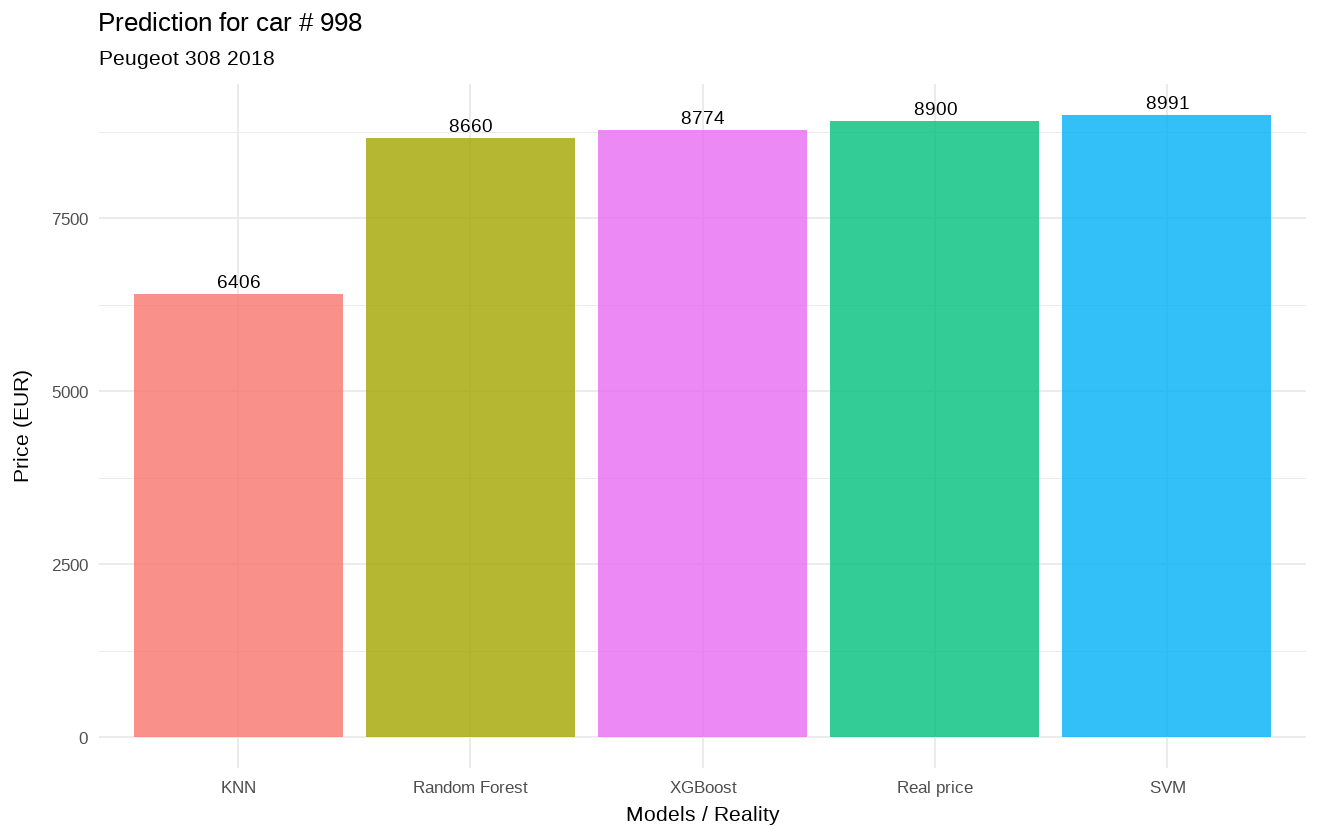

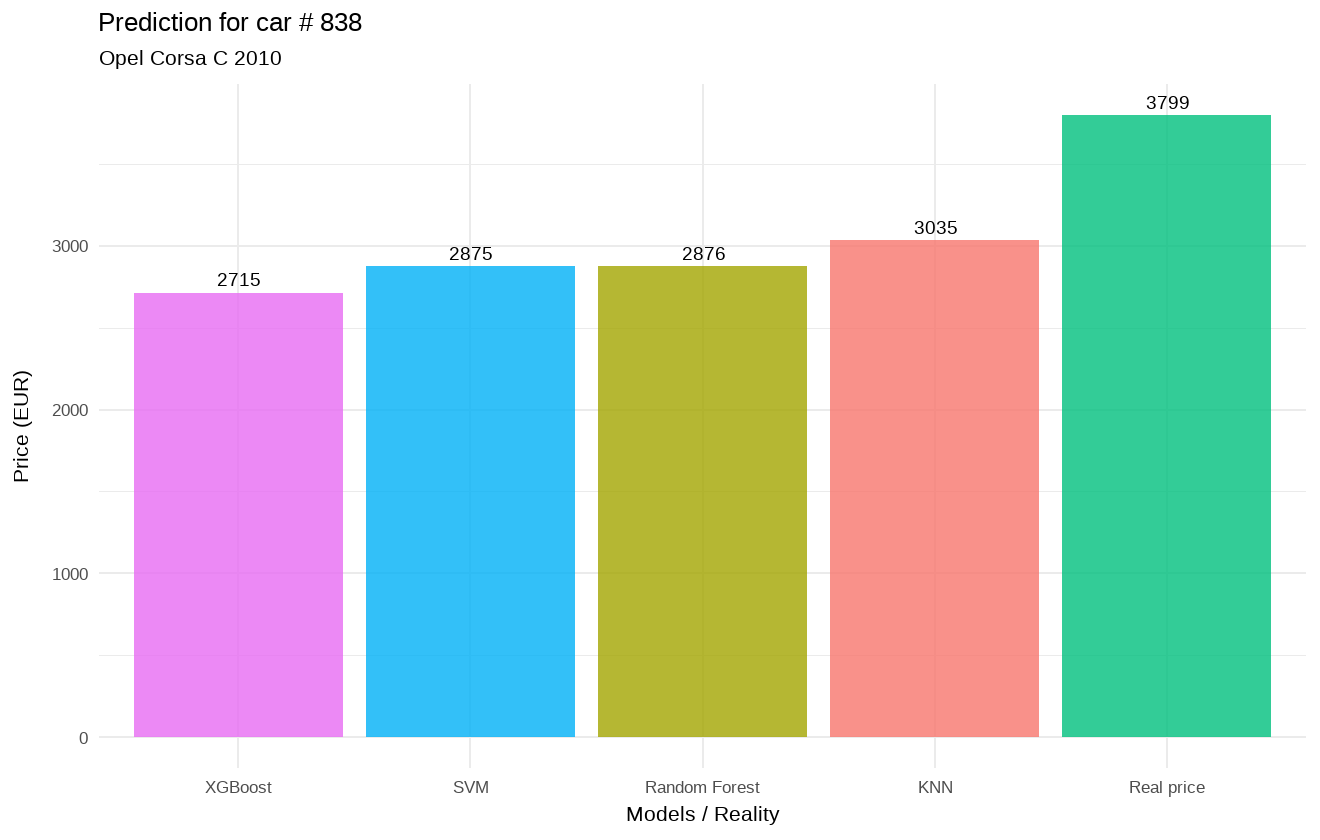

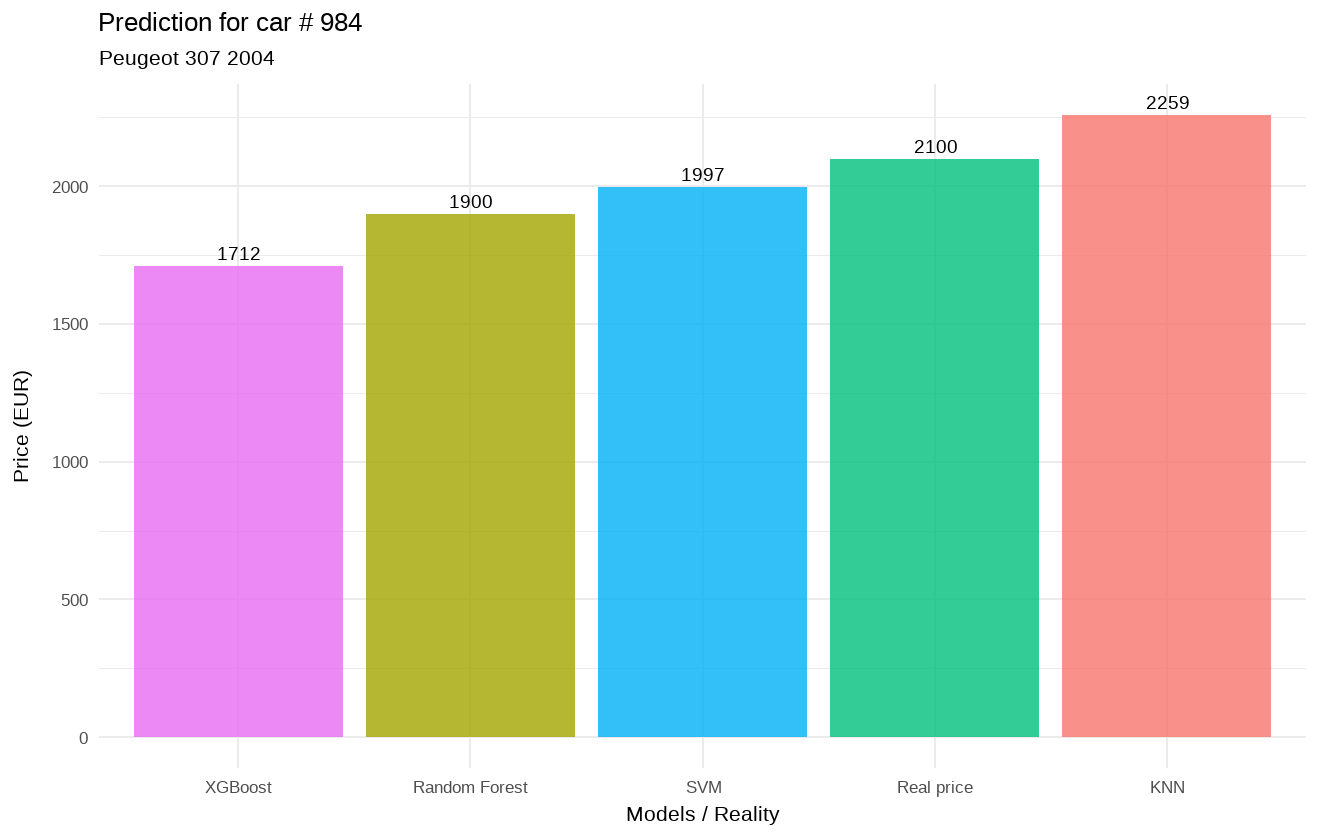

In [93]:
options(repr.plot.width = 11, repr.plot.height = 7)

set.seed(501)

car_test <- testing(car_split)
random_indices <- sample(1:nrow(car_test), 3)

walk(random_indices, function(idx) {
  random_car <- car_test %>% slice(idx)
  
  comparison <- data.frame(
    Type = c("Real price", "Random Forest", "XGBoost", "SVM", "KNN"),
    Price_EUR = c(
      car_test$price_eur[idx],
      final_predictions_rf$.pred[idx],
      final_predictions_xgb$.pred[idx],
      final_predictions_svm$.pred[idx],
      final_predictions_knn$.pred[idx]
    )
  )
  
  p <- ggplot(comparison, aes(x = reorder(Type, Price_EUR), y = Price_EUR, fill = Type)) +
    geom_col(alpha = 0.8) +
    geom_text(aes(label = round(Price_EUR, 0)), vjust = -0.5, size = 5) +
    theme_minimal(base_size = 16) +
    labs(title = paste("Prediction for car #", idx),
         subtitle = paste(random_car$brand, random_car$model, random_car$year),
         x = "Models / Reality", y = "Price (EUR)") +
    theme(legend.position = "none")
  
  print(p)
})
